# Placements and operators

PSBD detects a backdoor by perturbing a model $k$ times and flagging an input whose prediction barely moves. On a ResNet the original paper puts dropout in 1 place. A vision transformer offers many places and several kinds of perturbation fit each of them, so this repository swept a grid of positions and operators. This notebook explains that grid from the code up and then walks through it as the sequence of hypotheses it was: each step says the question and why it follows from the step before, what was measured and how, the figure, what it proves and does not prove and the question it leaves. `docs/placement-rationale.md` is the same argument in prose with the generated ledger of every number, and the hypothesis docs under `docs/hypothesis/` record each test as it was first run.

The reader is assumed to know PyTorch and transformers and nothing about this repository. Every term is defined where it first appears.

**Map of the steps.**

1. The vocabulary: position, operator, placement, the statistic and the 2 rate rules.
2. Every operator in `defenses/operators.py`, its code, the tensor it touches and a worked example on a toy tensor.
3. Every position in `models/positions.py` on ViT-B/16, Swin-S and ResNet-18: the hook, the module boundary and the tensor shape it sees, recorded live.
4. The panel and the ledger the sweep steps read.
5. The original site on its own architecture, the ResNet-18 control.
6. The ConvNet rate grid on ViT and why placements are compared at matched disturbance (H3, H9).
7. Before versus after the residual add (H1).
8. Sublayer input versus residual stream (H20).
9. Attention heads (H22, H35).
10. MLP neurons and whole channels (H16, H26).
11. DropPath, the residual-native perturbation (H21).
12. Whole tokens and removal versus disturbance (H23, H27, H47).
13. Where the token mask should act: attention input, MLP input, branch output or stream.
14. Ported perturbations from IBD-PSC and SCALE-UP (H17, H28).
15. Depth bands (H10, H38).
16. Transfer to Swin-S.
17. The whole grid at once, and the operators never swept.
18. Summary.

The notebook reads cached files only: `results/coverage/coverage.json`, `results/<folder>/psbd_metrics.json` and the Swin checkpoints' `args.json` sidecars. The live parts of steps 2 and 3 run randomly initialized models on the CPU to show shapes and code paths, and no trained checkpoint is loaded. It runs in a few minutes on a login node.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import inspect
import statistics
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms.v2 as transforms_v2
from IPython.display import Image, display
from matplotlib.patches import FancyBboxPatch
from torchvision.models import swin_s, vit_b_16

import defenses.operators as operators
import models.positions as positions
from defenses.decision import (
    ADAPTIVE_SHIFT_TARGET,
    HEADLINE_QUANTILE,
    PLACEMENT_MATCH_TARGET,
    PUBLISHED_PLACEMENT,
    RECOMMENDED_PLACEMENT,
)
from models.backbones import build_resnet18
from scripts.detector_doc_results import (
    PLACEMENT_RULES,
    placement_panel,
    placement_readings,
    resnet_control_reports,
)
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    attack_label,
    bootstrap_ci,
    load_declaration,
    load_psbd_metrics,
    split_placement,
)
from scripts.paper.tab_swin import swin_cells

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

warnings.filterwarnings("ignore", category=UserWarning)
# The login node has many cores and the toy models are tiny, so a small thread
# pool avoids spending more time on scheduling than on arithmetic.
torch.set_num_threads(8)
pd.set_option("display.max_colwidth", 80)
print("torch", torch.__version__)

torch 2.6.0+cu124


## Step 1. The vocabulary and the statistic

**Question.** What exactly is being varied, and what number judges each variant?

A **position** is where the perturbation is injected, a named tensor boundary that exists once in every block of the network (or once in the whole network). An **operator** is what is injected there. A **placement** is the pair, written `<position>_<operator>`. It is also the name of the cache directory `results/<folder>/psbd/<placement>/` that `cli.sweep` writes. A bare position name means the operator is dropout. A **band** such as `_blocks_5_8` restricts a placement to a contiguous range of blocks. The **rate** is the operator's strength: the dropout or masking probability $p$, or the noise scale for Gaussian noise. 2 placements have names used throughout: **PSBD-TM** is `before_attention_norm_token_mask`, whole tokens zeroed at the input of every attention branch, the placement this project recommends. **PSBD-RD** is `post_residual`, dropout on the residual stream right after both adds of every block, this project's adaptation of the PSBD paper's ResNet site.

PSBD (Li et al., arXiv 2406.05826) runs the input once unperturbed and $k$ times perturbed and scores how much the confidence of the unperturbed prediction drops. This project scores the fractional drop, `defenses.scores.psu_ratio_from_cache`:

$$
\phi_{ratio}(x) = 1 - \frac{1}{k} \sum_{i=1}^{k} \frac{P_c(x; p, \theta'_i)}{P_c(x; \theta)}, \qquad c = \arg\max_{c'} P_{c'}(x; \theta)
$$

| symbol | meaning |
|---|---|
| $x$ | the input image |
| $\theta$, $\theta'_i$ | the model unperturbed, and on perturbed pass $i$ with a fresh random draw |
| $p$ | the rate |
| $k$ | perturbed passes per input, 3 on the panel |
| $P_c$ | the softmax probability of class $c$ |
| $c$ | the unperturbed predicted class |
| $\phi_{ratio}(x)$ | the score, low meaning poisoned |

A clean input's evidence is destroyed by the perturbation, so its confidence falls and the score is high. A triggered input rides the backdoor, the most robust association the model learned, so its confidence barely moves and the score is low. The threshold is the 0.25 quantile of the scores of 2000 clean validation images, and AUROC is the probability that a random triggered image scores lower than its clean twin population, computed on the scores as they are and never flipped, so a value under 0.5 means the placement ordered the 2 populations the wrong way round.

The rate is chosen from clean data. The **shift ratio** $\sigma$ is the share of perturbed passes whose predicted class differs from the unperturbed one on the 2000 clean validation images (`defenses.scores.shift_ratio`). The **adaptive rule** (`select_rate_adaptively`) takes the smallest swept rate whose $\sigma$ reaches 0.8, the PSBD paper's target. It is the rule a defender can deploy. The **matched rule** (`select_rate_at_matched_shift`) takes the rate whose $\sigma$ is closest to 0.6 and exists to compare placements with each other at the same measured disturbance. Step 6 shows why it had to exist. The next cell prints the constants from `defenses.decision` so the text and the code cannot disagree.

**Next question.** What does each operator do to a tensor?

In [3]:
print(f"recommended placement (PSBD-TM): {RECOMMENDED_PLACEMENT}")
print(f"published placement (PSBD-RD):   {PUBLISHED_PLACEMENT}")
print(f"adaptive shift target:           {ADAPTIVE_SHIFT_TARGET}")
print(f"matched shift target:            {PLACEMENT_MATCH_TARGET}")
print(f"headline quantile:               {HEADLINE_QUANTILE}")
print(f"registered operators:            {sorted(operators.OPERATORS)}")
print(f"deterministic operators:         {sorted(operators.DETERMINISTIC_OPERATORS)}")
print(f"position restrictions:           {operators.OPERATOR_POSITIONS}")

recommended placement (PSBD-TM): before_attention_norm_token_mask
published placement (PSBD-RD):   post_residual
adaptive shift target:           0.8
matched shift target:            0.6
headline quantile:               0.25
registered operators:            ['channel_mask', 'dropout', 'droppath', 'gain_scale', 'gaussian', 'head_mask', 'rademacher', 'token_block_mask', 'token_mask', 'token_substitute']
deterministic operators:         ['gain_scale', 'scale_up']
position restrictions:           {'head_mask': ('attention_heads',), 'droppath': ('before_attention_residual', 'before_mlp_residual')}


## Step 2. The operators

**Question.** What does each operator touch, and how does it keep a perturbed pass comparable to an unperturbed one?

Every operator in `defenses/operators.py` is an `nn.Module` built from a rate that maps a tensor to a tensor of the same shape. Every operator follows 2 conventions of `nn.Dropout`, because PSU compares a perturbed pass with an unperturbed one and any systematic drift would read as signal. It is the identity in eval mode or at rate 0. Its expected output equals its input: an operator that removes entries divides the survivors by the keep probability $1 - p$ (`_keep_scale`), and an additive one adds noise of mean 0. The probes are attached outside the model's module tree, so `plug_dropout` sets them to train mode explicitly.

ViT tensors are (batch, tokens, channels), with token 0 the class token. Swin tensors are (batch, height, width, channels). The token operators flatten the 2 spatial axes into 1 token axis with `_to_token_layout` and restore them afterwards.

The worked examples below use a toy activation of 1 sample, 17 tokens (1 class token plus a 4 by 4 grid of patches) and 12 channels, filled with 1 so every change is visible as a color. Each figure shows the tensor before the operator and after it, and its title gives the share of entries zeroed and the share changed in any way, which for a removing operator includes the survivors rescaled by $1 / (1 - p)$. The rows are tokens and the columns are channels. What the toy figures do NOT show is any effect on detection, which steps 5 to 17 read from the sweep.

In [4]:
TOKENS, CHANNELS = 17, 12
toy = torch.ones(1, TOKENS, CHANNELS)  # (batch, tokens, channels)


def apply_operator(operator, x, seed=0):
    # The probe is outside the model tree in real use, so train mode is set here
    # exactly as plug_dropout sets it.
    torch.manual_seed(seed)
    operator.train()
    with torch.no_grad():
        return operator(x)


def show_before_after(before, after, title, axis_labels=("token", "channel")):
    before_2d = before.reshape(-1, before.shape[-1]).numpy()  # (rows, columns)
    after_2d = after.reshape(-1, after.shape[-1]).numpy()
    changed = float((after_2d != before_2d).mean())
    zeroed = float(((after_2d == 0) & (before_2d != 0)).mean())
    figure, axes = plt.subplots(1, 2, figsize=(6.4, 2.6))
    low = min(before_2d.min(), after_2d.min())
    high = max(before_2d.max(), after_2d.max())
    for axis, grid, name in zip(axes, (before_2d, after_2d), ("before", "after")):
        image = axis.imshow(grid, cmap="viridis", vmin=low, vmax=high, aspect="auto")
        axis.set_title(name)
        axis.set_xlabel(axis_labels[1])
        axis.set_ylabel(axis_labels[0])
        axis.grid(False)
    figure.colorbar(image, ax=axes, fraction=0.03, label="value")
    figure.suptitle(f"{title}: {zeroed:.0%} of entries zeroed, {changed:.0%} changed in any way", fontsize=8)
    plt.show()

**Dropout.**

`nn.Dropout` is the PSBD paper's operator. It zeroes each entry independently with probability $p$ and divides the survivors by $1 - p$:

$$
y = \frac{m \odot x}{1 - p}, \qquad m_{t,d} \sim \text{Bernoulli}(1 - p) \text{ independently for every token } t \text{ and channel } d
$$

| symbol | meaning |
|---|---|
| $x$, $y$ | the activation before and after |
| $m$ | the random keep mask, same shape as $x$ |
| $\odot$ | elementwise product |
| $p$ | the drop probability |

On a (197, 768) activation that is 151296 independent decisions, so every token keeps most of its channels and every channel survives in most tokens. Dropout thins everything a little and removes no unit whole, which is what motivated the structured operators below ([H26](../docs/hypothesis/H26-channel-mask-structured-vs-elementwise.md)). The source printed is `_keep_scale`, the inverted-scaling factor every removing operator of this module shares.

def _keep_scale(rate: float) -> float:
    """Inverted-dropout scale, the 1 / (1 - p) factor applied to survivors.

        original form
            y = (m * x) / (1 - p),   m ~ Bernoulli(1 - p)

        descriptive form
            survivor = kept_value / keep_probability

    so the expected output equals the input and the perturbed pass stays on the
    same scale as the unperturbed pass. Guarded because rate 1.0 would divide by 0.
    """
    keep_probability = 1.0 - rate
    if keep_probability <= 0.0:
        raise ValueError(f"rate {rate} removes everything, leaving nothing to scale")
    scale = 1.0 / keep_probability
    return scale



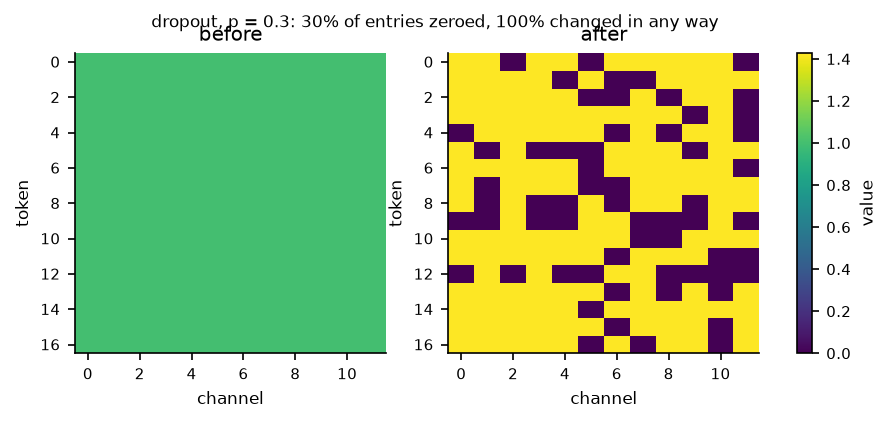

mean of the output 1.001, the expectation is kept near 1 by the 1 / (1 - p) scaling


In [5]:
print(inspect.getsource(operators._keep_scale))
after = apply_operator(nn.Dropout(0.3), toy)
show_before_after(toy, after, "dropout, p = 0.3")
print(f"mean of the output {after.mean():.3f}, the expectation is kept near 1 by the 1 / (1 - p) scaling")

**Token mask.**

`TokenMask` zeroes every channel of a chosen token but never the class token, because token 0 is the only token ViT's head reads and dropping it would destroy the prediction instead of perturbing it. On Swin there is no class token and nothing is protected. It is the operator of PSBD-TM. The unit is spatial: a patch token covers a 16 by 16 pixel patch, so masking tokens is the transformer's version of occluding image regions, and a patch trigger occupies a handful of tokens ([H27](../docs/hypothesis/H27-token-mask-trigger-locality.md)).

$$
y_{t,:} = \frac{m_t \, x_{t,:}}{1 - p}, \qquad m_t \sim \text{Bernoulli}(1 - p), \quad m_0 = 1 - p \text{ so that } y_{0,:} = x_{0,:}
$$

| symbol | meaning |
|---|---|
| $t$ | a token index, 0 the class token |
| $x_{t,:}$ | all channels of token $t$ |
| $m_t$ | 1 keep draw per token, shared by all its channels |

    def _mask_tokens(self, x: torch.Tensor, protect_cls: bool) -> torch.Tensor:
        """x with whole tokens zeroed, (batch, tokens, channels) in and out."""
        batch, tokens, _ = x.shape  # (batch, tokens, channels)
        keep = torch.empty(batch, tokens, 1, device=x.device, dtype=x.dtype).bernoulli_(
            1.0 - self.rate
        )  # (batch, tokens, 1)
        keep *= _keep_scale(self.rate)
        if protect_cls:
            keep[:, 0, :] = 1.0

        masked = x * keep  # (batch, tokens, channels)
        return masked



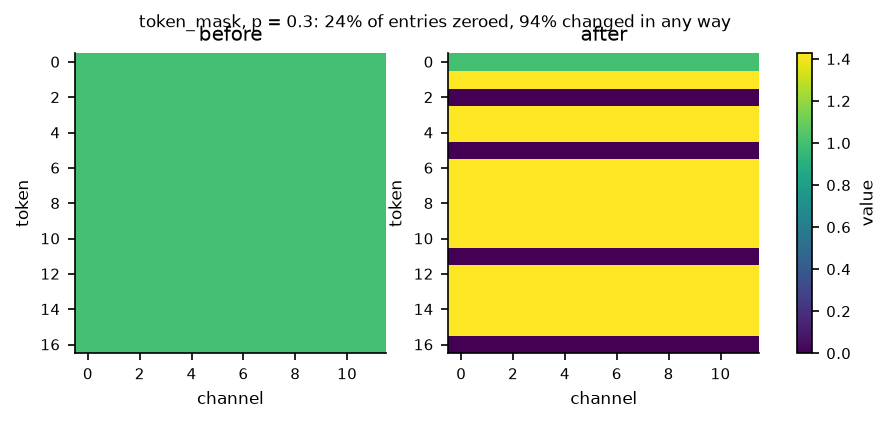

class token row unchanged: True


In [6]:
print(inspect.getsource(operators.TokenMask._mask_tokens))
after = apply_operator(operators.TokenMask(0.3), toy)
show_before_after(toy, after, "token_mask, p = 0.3")
print("class token row unchanged:", bool(torch.equal(after[0, 0], toy[0, 0])))

**Channel mask.**

`GroupChannelMask` (registered as `channel_mask`, with group size 1) zeroes whole channels, 1 draw per (sample, channel) shared by every token of the sample. A removed channel contributes nothing anywhere in the sample, which is what "removing a feature" means. At the `mlp_neurons` position a channel is 1 of the 3072 hidden neurons of the MLP, so the same operator removes whole neurons there.

    def _mask_channels(self, x: torch.Tensor) -> torch.Tensor:
        """x with whole channel groups zeroed, (batch, tokens, channels) in and out.

        Raises when the channels do not divide into groups of group_size.
        """
        batch, _, channels = x.shape  # (batch, tokens, channels)
        if channels % self.group_size:
            raise ValueError(
                f"{channels} channels do not divide into groups of {self.group_size}"
            )

        groups = channels // self.group_size
        keep = torch.empty(batch, 1, groups, device=x.device, dtype=x.dtype).bernoulli_(
            1.0 - self.rate
        )  # (batch, 1, groups)
        mask = keep.repeat_interleave(self.group_size, dim=2)  # (batch, 1, channels)

        masked = x * mask * _keep_scale(self.rate)  # (batch, tokens, channels)
        return masked



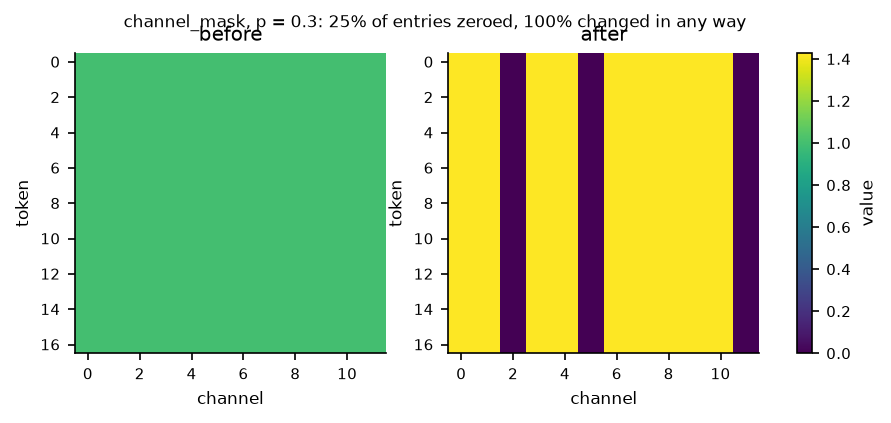

In [7]:
print(inspect.getsource(operators.GroupChannelMask._mask_channels))
after = apply_operator(operators.channel_mask(0.3), toy)
show_before_after(toy, after, "channel_mask, p = 0.3")

**Head mask.**

`HeadMask` zeroes whole attention heads of the per-head tensor (batch, heads, tokens, head dim), which exists only inside the attention computation. It therefore works only at `attention_heads`, where `masked_attention_forward` recomputes attention so the head axis is reachable, and `OPERATOR_POSITIONS` refuses it anywhere else. The toy tensor here has 4 heads of 6 tokens by 5 dims, drawn as the 4 heads stacked vertically. `FixedHeadMask` is its deterministic sibling that removes 1 named head without rescaling, a leave-one-out tool for [H18](../docs/hypothesis/H18-sensitivity-profile-over-units.md) rather than a placement.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x with whole heads zeroed, (batch, heads, tokens, dim) in and out.

        Raises on any other rank, since only the attention wrapper produces the
        per-head layout.
        """
        if not self.training or self.rate == 0.0:
            return x
        if x.dim() != 4:
            raise ValueError(
                f"expected (batch, heads, tokens, dim), got {tuple(x.shape)}"
            )

        batch, heads = x.shape[0], x.shape[1]
        keep = torch.empty(
            batch, heads, 1, 1, device=x.device, dtype=x.dtype
        ).bernoulli_(1.0 - self.rate)  # (batch, heads, 1, 1)

        masked = x * keep * _keep_scale(self.rate)  # (batch, heads, tokens, dim)
        return masked



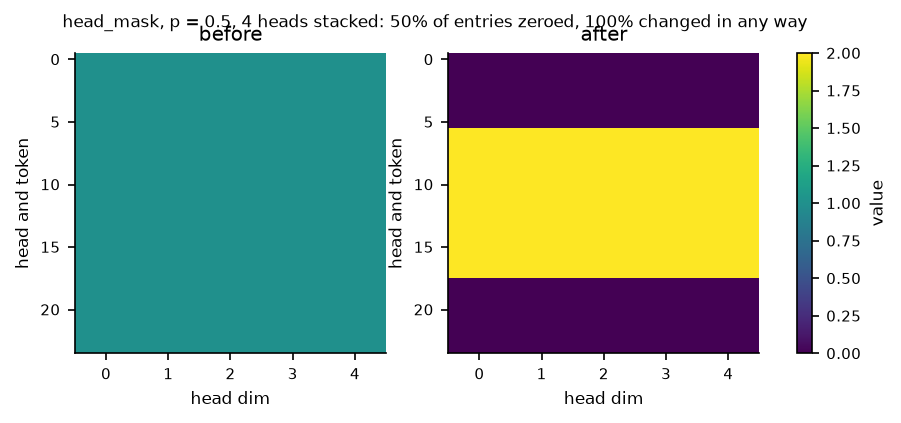

In [8]:
print(inspect.getsource(operators.HeadMask.forward))
per_head = torch.ones(1, 4, 6, 5)  # (batch, heads, tokens, head dim)
after = apply_operator(operators.HeadMask(0.5), per_head, seed=1)
show_before_after(
    per_head.reshape(1, 24, 5), after.reshape(1, 24, 5), "head_mask, p = 0.5, 4 heads stacked",
    axis_labels=("head and token", "head dim"),
)

**DropPath.**

`DropPath` zeroes a whole branch output for a whole sample, the stochastic depth ViT is trained with. Attached at `before_attention_residual` or `before_mlp_residual` it makes that block's branch contribute nothing for that sample, so the block becomes the identity for it. It removes a computation rather than a feature ([H21](../docs/hypothesis/H21-droppath-residual-native.md)), and only the 2 branch-output positions accept it. The toy here is a batch of 6 samples, so the figure's rows are samples.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x with whole samples zeroed, any layout with batch first, same shape out."""
        if not self.training or self.rate == 0.0:
            return x

        # A single Bernoulli draw per sample, broadcast over every other axis, so
        # the layout does not matter and both ViT and Swin are handled unchanged.
        sample_shape = (x.shape[0],) + (1,) * (x.dim() - 1)
        keep = torch.empty(sample_shape, device=x.device, dtype=x.dtype).bernoulli_(
            1.0 - self.rate
        )  # (batch, 1, ..., 1)

        masked = x * keep * _keep_scale(self.rate)  # same shape as x
        return masked



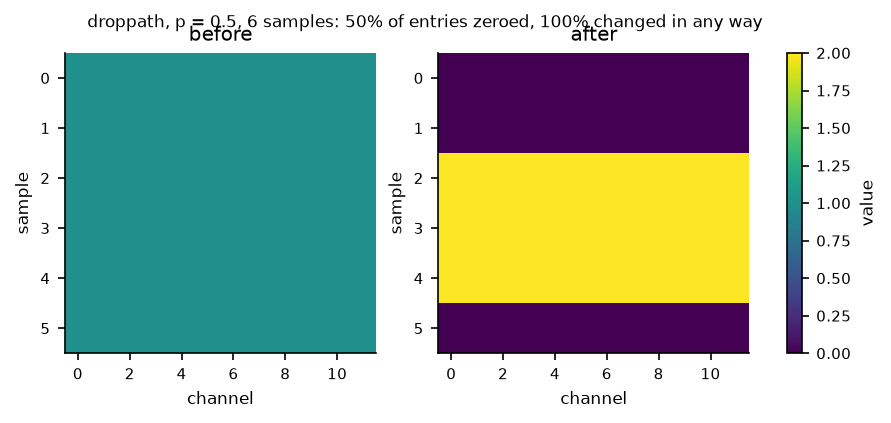

In [9]:
print(inspect.getsource(operators.DropPath.forward))
batch = torch.ones(6, 1, CHANNELS)  # (batch, 1 token, channels)
after = apply_operator(operators.DropPath(0.5), batch, seed=2)
show_before_after(batch, after, "droppath, p = 0.5, 6 samples", axis_labels=("sample", "channel"))

**Gaussian noise and Rademacher noise.**

`GaussianNoise` adds isotropic noise at the activation's own scale and removes nothing. It is the control that asks whether PSBD needs capacity removed or only disturbed ([H23](../docs/hypothesis/H23-gaussian-noise-control.md)).

$$
y = x + \epsilon, \qquad \epsilon \sim \mathcal{N}\big(0, (p \, s)^2 I\big), \qquad s = \operatorname{std}(x) \text{ over every axis but the batch}
$$

| symbol | meaning |
|---|---|
| $s$ | the standard deviation of the sample's own activation |
| $p$ | the rate, read as a relative noise scale |
| $\epsilon$ | the noise, mean 0 so no rescaling is needed |

The scale is computed per sample on purpose: a batch-wide scale would make 1 sample's noise depend on which other samples share its batch, and the retired arm under `archive/gaussian_batchstd` had that fault. `RademacherNoise` draws $\pm p \, s$ signs instead of a normal, the same covariance with lower estimator variance, and exists to test the trace-estimator reading of PSBD in `docs/theory-perturbation-consistency.md`. It was never swept. The toy input here is random, since noise on a constant tensor would have a scale of 0.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x plus noise at rate times its own spread, any layout, same shape out."""
        if not self.training or self.rate == 0.0:
            return x

        non_batch_axes = tuple(range(1, x.dim()))
        scale = x.detach().std(dim=non_batch_axes, keepdim=True)  # (batch, 1, ..., 1)

        noised = x + torch.randn_like(x) * (self.rate * scale)  # same shape as x
        return noised



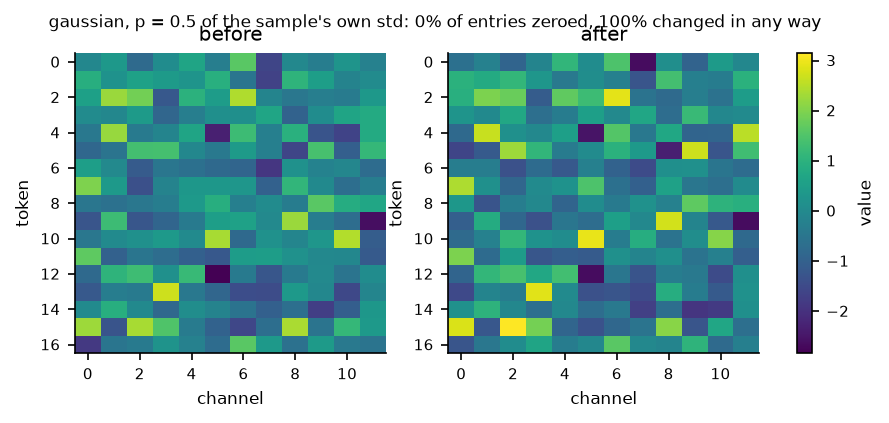

rademacher noise magnitudes: [0.5004000067710876]


In [10]:
print(inspect.getsource(operators.GaussianNoise.forward))
torch.manual_seed(3)
random_toy = torch.randn(1, TOKENS, CHANNELS)  # (batch, tokens, channels)
after = apply_operator(operators.GaussianNoise(0.5), random_toy)
show_before_after(random_toy, after, "gaussian, p = 0.5 of the sample's own std")
after = apply_operator(operators.RademacherNoise(0.5), random_toy)
print("rademacher noise magnitudes:", torch.unique((after - random_toy).abs().round(decimals=4)).tolist())

**Gain scale.**

`GainScale` multiplies its input by $1 + p$ and is deterministic. At a LayerNorm output it is the IBD-PSC perturbation (Hou et al., ICML 2024): scaling a LayerNorm's $\gamma$ and $\beta$ together equals scaling its output, $\omega \gamma \odot \hat{x} + \omega \beta = \omega (\gamma \odot \hat{x} + \beta)$ with $\omega = 1 + p$, so a post-hook reproduces it without touching a weight. Because every pass is identical, 1 pass is exact.

In [11]:
print(inspect.getsource(operators.GainScale.forward))
after = apply_operator(operators.GainScale(0.5), random_toy)
print("output / input ratio:", torch.unique((after / random_toy).round(decimals=4)).tolist())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x times 1 + rate, any layout, same shape out."""
        if not self.training or self.rate == 0.0:
            return x

        amplified = x * (1.0 + self.rate)  # same shape as x
        return amplified

output / input ratio: [1.5]


**Scale up.**

`ScaleUp` is SCALE-UP's pixel amplification (Guo et al., ICLR 2023) as an operator. It denormalizes the image, multiplies every pixel by $1 + p$, clips to $[0, 1]$ and renormalizes, so the clip, where the method's nonlinearity lives, happens in pixel space. It needs the dataset's normalization statistics, so it is built through the `scale_up(mean, std)` factory rather than from a rate alone, and it only makes sense at `input_pixels`. The example uses a smooth toy image with an identity normalization.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """The amplified image, (batch, channels, height, width) in and out."""
        if not self.training or self.rate == 0.0:
            return x

        mean = self.mean.to(x.device, x.dtype)  # (1, channels, 1, 1)
        std = self.std.to(x.device, x.dtype)  # (1, channels, 1, 1)

        pixels = (x * std + mean).clamp(0.0, 1.0)  # (batch, channels, height, width)
        amplified = (pixels * (1.0 + self.rate)).clamp(0.0, 1.0)  # same shape

        renormalized = (amplified - mean) / std  # (batch, channels, height, width)
        return renormalized



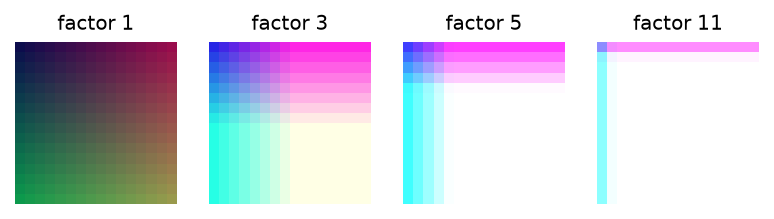

In [12]:
print(inspect.getsource(operators.ScaleUp.forward))
ramp = torch.linspace(0.05, 0.6, 16)
toy_image = torch.stack([ramp[None, :].expand(16, 16), ramp[:, None].expand(16, 16), torch.full((16, 16), 0.3)])[None]  # (1, 3, 16, 16)
figure, axes = plt.subplots(1, 4, figsize=(6.4, 1.8))
for axis, factor in zip(axes, (1, 3, 5, 11)):
    amplified = apply_operator(operators.ScaleUp(factor - 1, (0.0, 0.0, 0.0), (1.0, 1.0, 1.0)), toy_image)
    axis.imshow(amplified[0].permute(1, 2, 0).numpy())
    axis.set_title(f"factor {factor}")
    axis.axis("off")
plt.show()

**Token substitute and token block mask.**

2 operators were written after the basis was fixed and have no cache on any panel model. `TokenSubstitute` replaces chosen patch tokens with other tokens of the same sample, taken by rolling the token axis by a random nonzero amount per sample, so the input stays on the data manifold while the token's content is removed. It would say how much of PSBD-TM's gain is the zero token itself. `TokenBlockMask` zeroes a square block of the patch grid whose area is the rate, a control for trigger geometry: it should help a patch trigger and do nothing special for a whole-image one. Their docstrings, and `docs/placement-rationale.md` step 14, record why each exists. `docs/perturbations.md` describes the substitute as borrowing from another sample of the batch, which the code deliberately does not do.

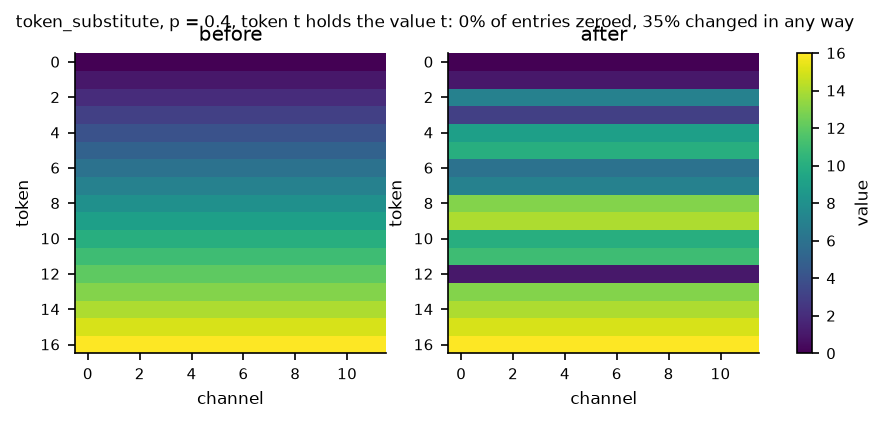

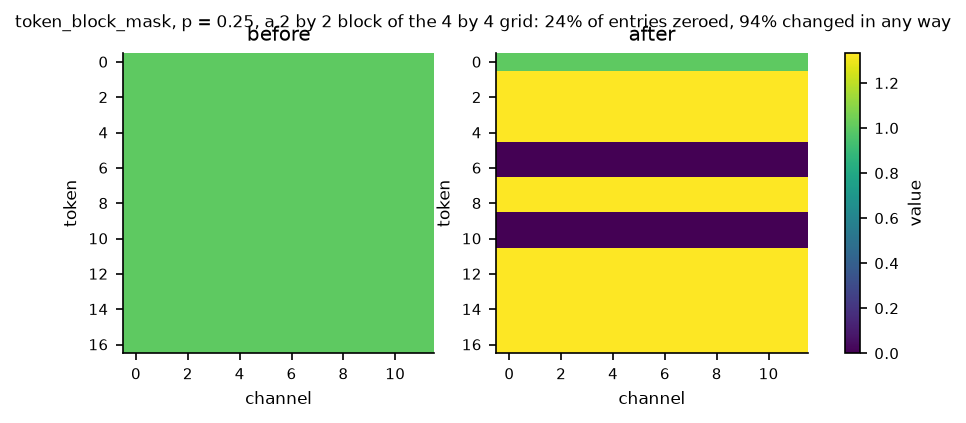

In [13]:
ordered = torch.arange(TOKENS, dtype=torch.float32)[None, :, None].expand(1, TOKENS, CHANNELS).clone()  # (1, 17, 12), token t holds value t
after_substitute = apply_operator(operators.TokenSubstitute(0.4), ordered, seed=4)
after_block = apply_operator(operators.TokenBlockMask(0.25), toy, seed=4)
show_before_after(ordered, after_substitute, "token_substitute, p = 0.4, token t holds the value t")
show_before_after(toy, after_block, "token_block_mask, p = 0.25, a 2 by 2 block of the 4 by 4 grid")

**Forbidden pairs.**

`check_operator_position` refuses the operator and position pairs that would run without error and produce a plausible wrong answer: a structured operator on the raw image, where a rank-4 image would be read as Swin's (batch, height, width, channels) layout, a token mask after the final LayerNorm, where ViT's head reads only the protected class token, and the 2 restricted operators away from their positions.

**What step 2 proves.** Each operator touches exactly the axis its name says and keeps the expected activation. The registry refuses the positions where an operator would be meaningless. **What it does not.** Which of them detects backdoors. **Next question.** Where in the network can they be attached, and what tensor arrives there?

In [14]:
for operator, position in [("token_mask", "input_pixels"), ("token_mask", "final_norm_out"), ("head_mask", "before_mlp"), ("droppath", "before_attention_norm"), ("token_mask", "before_attention_norm")]:
    try:
        operators.check_operator_position(operator, position)
        print(f"{operator:12s} at {position:22s} allowed")
    except ValueError as error:
        print(f"{operator:12s} at {position:22s} refused: {str(error)[:90]}...")

token_mask   at input_pixels           refused: token_mask at input_pixels: input_pixels carries a (batch, channels, height, width) image,...
token_mask   at final_norm_out         refused: token_mask at final_norm_out: final_norm_out sits after the final LayerNorm, and ViT's hea...
head_mask    at before_mlp             refused: head_mask is only meaningful at ('attention_heads',), not at 'before_mlp'...
droppath     at before_attention_norm  refused: droppath is only meaningful at ('before_attention_residual', 'before_mlp_residual'), not a...
token_mask   at before_attention_norm  allowed


## Step 3. The positions

**Question.** At which tensor boundaries can a probe attach? By what mechanism, and what shape does it see?

`models/positions.py` holds 1 table per architecture in `POSITION_REGISTRY`, mapping a position name to a `PositionSpec(submodule_name, hook_type, scope)`. `plug_dropout(model, architecture, position_names, dropout_factory, rate, block_range)` resolves every target and attaches a fresh operator. The hook types are `pre` (a forward pre-hook on the module's first positional input), `post` (a forward hook on its output), `residual` (a per-instance replacement of the block's `forward`, because the stream right after the attention add is a local variable that never crosses a module boundary) and `attention` (a per-instance replacement of the attention forward, because the per-head outputs live inside `F.multi_head_attention_forward`). The scope says where the name resolves: `block` in every transformer block, `model` once under the network, `root` once on the `Sequential(Resize, network)` wrapper. `unplug_dropout` removes every attachment by handle and no weight is ever changed.

The table below is the registry itself, for the 3 architectures.

In [15]:
rows = []
for architecture, table in positions.POSITION_REGISTRY.items():
    for name, spec in table.items():
        rows.append({"architecture": architecture, "position": name, "module": spec.submodule_name or "(the block itself)", "hook": spec.hook_type, "scope": spec.scope})
registry = pd.DataFrame(rows)
print(f"combinations: {positions.DROPOUT_CONFIGS}")
registry

combinations: {'pre_residual': ('before_attention_residual', 'before_mlp_residual'), 'post_residual': ('after_attention_residual', 'after_mlp_residual'), 'both_sublayer_inputs': ('before_attention_norm', 'before_mlp_norm')}


,architecture,position,module,hook,scope
0,vit,after_embedding,encoder.dropout,pre,model
1,vit,before_attention_norm,ln_1,pre,block
2,vit,before_attention,self_attention,pre,block
3,vit,attention_heads,self_attention,attention,block
4,vit,before_attention_residual,dropout,post,block
5,vit,before_mlp_norm,ln_2,pre,block
6,vit,after_attention_residual,(the block itself),residual,block
7,vit,before_mlp,mlp,pre,block
8,vit,mlp_neurons,mlp.3,pre,block
9,vit,before_mlp_residual,mlp,post,block


The ViT-B/16 block, pre-norm form: $x' = x + \text{dropout}(\text{MSA}(\text{ln\_1}(x)))$, then $y = x' + \text{mlp}(\text{ln\_2}(x'))$. The diagram below, rendered from `notebooks/figures/vit_block_positions.tex`, marks every ViT position on 1 block, PSBD-TM in green and the 2 stream points of PSBD-RD in orange. The distinction the whole study turns on is between a branch (the attention or MLP sub-computation, whose output is added to the stream) and the stream itself (the running sum every later block reads).

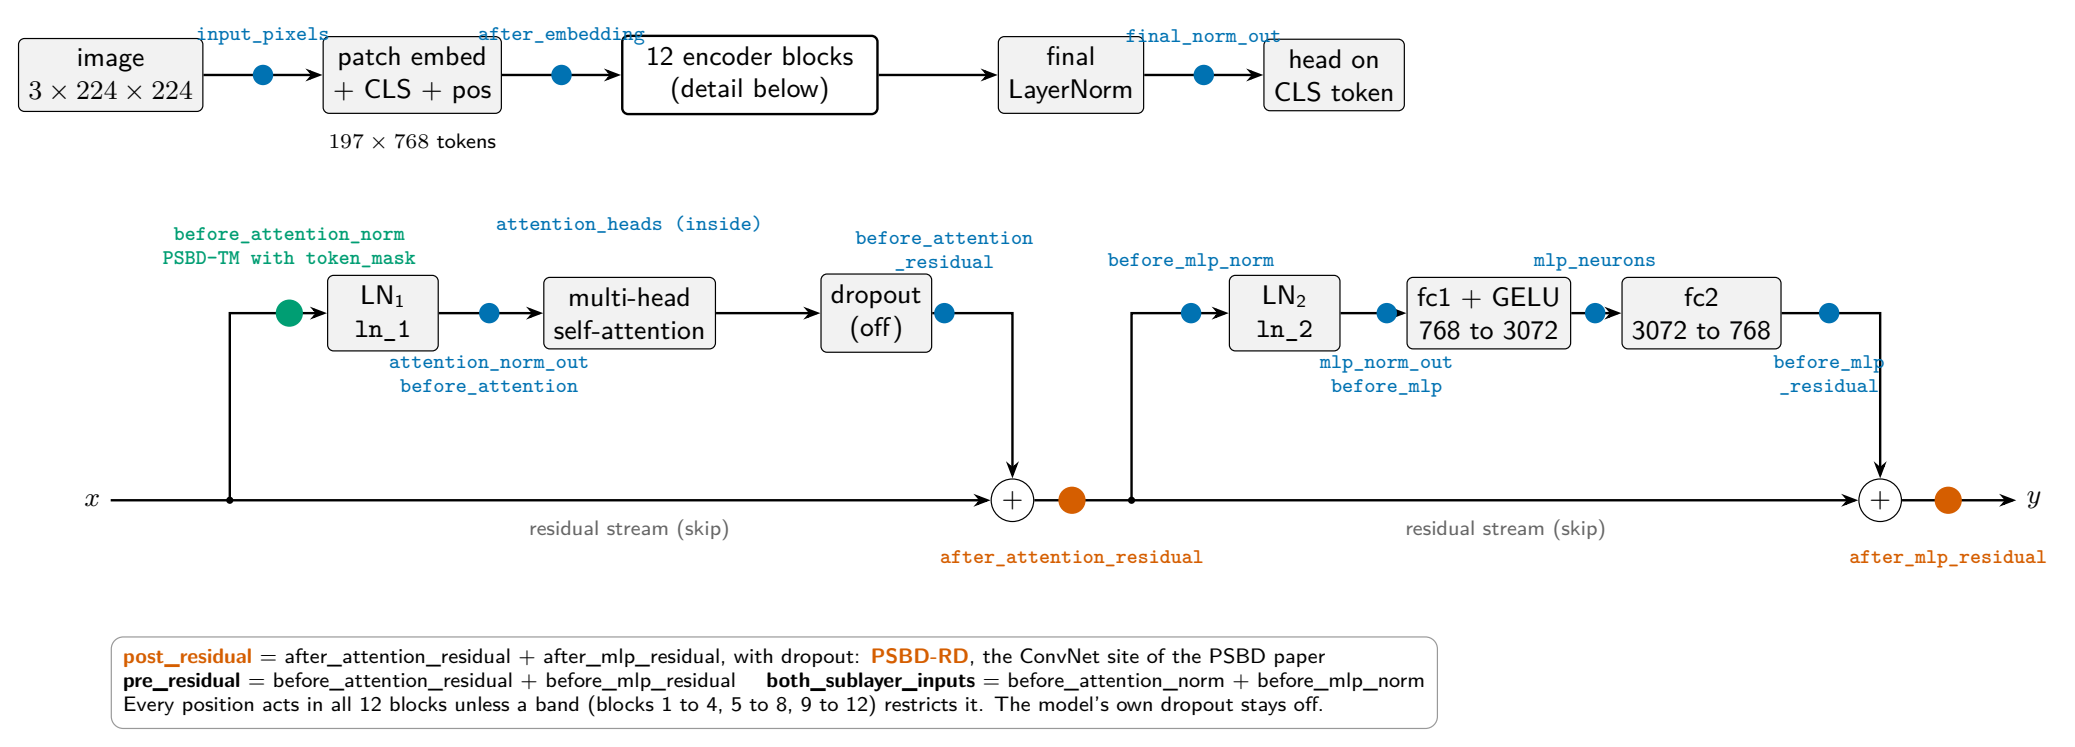

In [16]:
display(Image(filename="notebooks/figures/vit_block_positions.png", width=900))

The 2 positions that need a replaced forward are easiest to understand from their source. `_vit_post_attention_residual_forward` is torchvision's `EncoderBlock.forward` with 1 extra call, the probe applied to `x + input_tensor` before both the MLP branch and the skip read it. `masked_attention_forward` recomputes multi-head attention from the loaded `in_proj_weight` so that the (batch, heads, tokens, head dim) tensor exists and the probe can act on it.

In [17]:
print(inspect.getsource(positions._vit_post_attention_residual_forward))
print(inspect.getsource(operators.masked_attention_forward))

def _vit_post_attention_residual_forward(
    block: nn.Module, probe: nn.Module, input_tensor
):
    """EncoderBlock.forward with the probe on the stream after the attention add.

    input_tensor is the (batch, tokens, dim) residual stream entering the block
    and the return is the stream leaving it, in the same shape. Mirrors
    torchvision's EncoderBlock.forward exactly except for the single probe call.
    The MLP-branch add is left alone: after_mlp_residual is a plain post-hook on
    the block, so plugging both positions composes into the full post-residual
    placement without either mechanism knowing about the other.
    """
    x = block.ln_1(input_tensor)  # (batch, tokens, dim)
    x, _ = block.self_attention(x, x, x, need_weights=False)  # (batch, tokens, dim)
    x = block.dropout(x)  # (batch, tokens, dim)
    x = probe(x + input_tensor)  # (batch, tokens, dim)
    y = block.ln_2(x)  # (batch, tokens, dim)
    y = block.mlp(y)  # (batch, tokens, dim)

    out = x + y

**Recording the shape at every position.** The cell below builds the real architectures with random weights, ViT-B/16 and Swin-S from torchvision and the ResNet-18 of `models.backbones.build_resnet18` (random weights change no shape), attaches at each position a recording probe that stores the shape it receives and passes the tensor through unchanged, and runs 1 image of 32 by 32 pixels. The ViT and Swin wrappers resize it to 224 as the real models do, and ResNet-18 runs at its native 32 pixels. The columns give how many attachments the position makes (12 on ViT, 24 on Swin, 8 on ResNet for a block-scope position) and the shape seen in the first and the last attachment.

In [18]:
class ShapeRecorder(nn.Module):
    # Passes the tensor through unchanged and remembers the shape it saw, so the
    # recorded shapes are the ones a real operator would receive.
    def __init__(self, log):
        super().__init__()
        self.log = log

    def forward(self, x):
        self.log.append(tuple(x.shape))
        return x


def wrapped(network):
    model = nn.Sequential(transforms_v2.Resize((224, 224)), network)
    return model.eval()


def recorded_shapes(model, architecture):
    image = torch.rand(1, 3, 32, 32)  # (batch, channels, height, width)
    rows = []
    for name in positions.POSITION_REGISTRY[architecture]:
        log = []
        handles = positions.plug_dropout(model, architecture, (name,), {name: lambda rate, log=log: ShapeRecorder(log)}, 0.1)
        with torch.no_grad():
            model(image)
        positions.unplug_dropout(handles)
        rows.append({"architecture": architecture, "position": name, "attachments": len(log), "first shape": log[0], "last shape": log[-1]})
    return rows


torch.manual_seed(0)
shape_rows = recorded_shapes(wrapped(vit_b_16(weights=None)), "vit")
shape_rows += recorded_shapes(wrapped(swin_s(weights=None)), "swin")
shape_rows += recorded_shapes(build_resnet18(10).eval(), "resnet18")
shapes = pd.DataFrame(shape_rows)
shapes

,architecture,position,attachments,first shape,last shape
0,vit,after_embedding,1,"(1, 197, 768)","(1, 197, 768)"
1,vit,before_attention_norm,12,"(1, 197, 768)","(1, 197, 768)"
2,vit,before_attention,12,"(1, 197, 768)","(1, 197, 768)"
3,vit,attention_heads,12,"(1, 12, 197, 64)","(1, 12, 197, 64)"
4,vit,before_attention_residual,12,"(1, 197, 768)","(1, 197, 768)"
5,vit,before_mlp_norm,12,"(1, 197, 768)","(1, 197, 768)"
6,vit,after_attention_residual,12,"(1, 197, 768)","(1, 197, 768)"
7,vit,before_mlp,12,"(1, 197, 768)","(1, 197, 768)"
8,vit,mlp_neurons,12,"(1, 197, 3072)","(1, 197, 3072)"
9,vit,before_mlp_residual,12,"(1, 197, 768)","(1, 197, 768)"


**Reading the table.** On ViT every block-scope position sees (1, 197, 768): 196 patch tokens of a 14 by 14 grid plus the class token, 768 channels. `mlp_neurons` sees the MLP's hidden layer (1, 197, 3072) and `attention_heads` sees 12 heads of 64 dims (1, 12, 197, 64). `after_embedding` and `final_norm_out` attach once. `input_pixels` sees the 32 by 32 image before the Resize, which is where SCALE-UP's clip has to happen. On Swin the tensors are (batch, height, width, channels), 56 by 56 by 96 in the first stage and 7 by 7 by 768 in the last, over 24 blocks. Swin has no `attention_heads` or `mlp_neurons` entry. Its `before_attention_residual` hooks the output of `attn` because a single `stochastic_depth` instance serves both branches and a hook on it could not tell which branch called it. ResNet-18 has 1 site in each of its 8 `BasicBlock`s. The 2 ViT stream names are aliases for it so that a command written for ViT runs on the control.

The next cell draws the Swin and ResNet blocks with their positions. The ViT diagram above has its own figure. **What step 3 proves.** The code path and the tensor of every position, measured on the real architectures. **What it does not.** Which position detects, which the sweep steps answer. **Next question.** Which models and which cached numbers do those steps read?

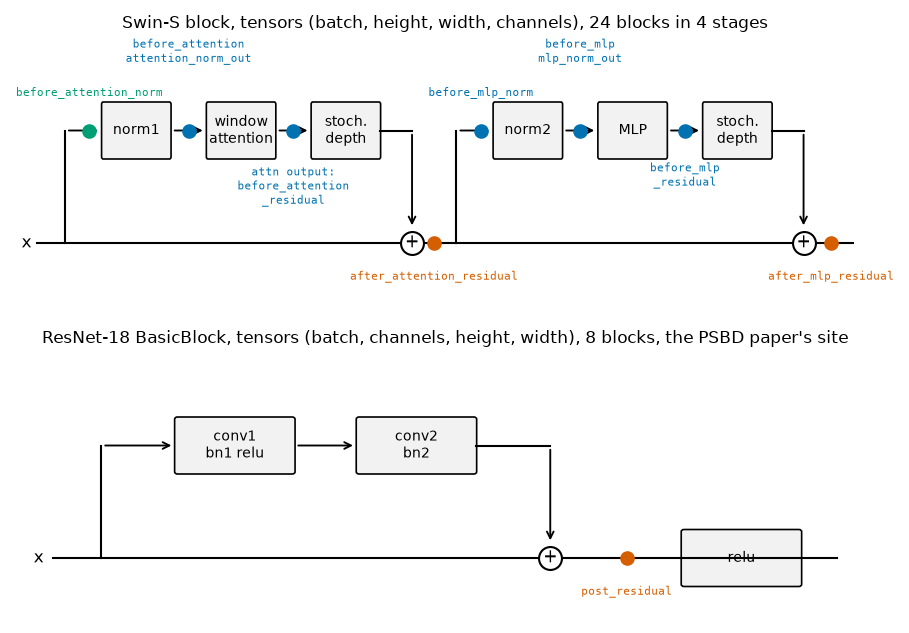

In [19]:
def branch_box(axis, x, y, label):
    axis.add_patch(FancyBboxPatch((x - 0.6, y - 0.35), 1.2, 0.7, boxstyle="round,pad=0.03", facecolor="#F2F2F2", edgecolor="black", lw=0.8))
    axis.text(x, y, label, ha="center", va="center", fontsize=6.5)


def arrow(axis, start, end):
    axis.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=0.9))


def marker(axis, x, y, label, color, height):
    axis.plot([x], [y], marker="o", markersize=6, color=color, zorder=5)
    axis.text(x, y + height, label, ha="center", va="center", fontsize=5.5, color=color, family="monospace")


def residual_block(axis, branches, stream_markers, end, title, after_add=None):
    # branches: list of (split_x, add_x, [(box_x, label)], [(x, label, color, label_height)]).
    # The stream runs along y = 0, each branch leaves it at split_x, runs along
    # y = 1.5 through its boxes and is added back at add_x.
    axis.plot([0, end], [0, 0], color="black", lw=1)
    for split_x, add_x, boxes, markers in branches:
        axis.plot([split_x, split_x], [0, 1.5], color="black", lw=1)
        arrow(axis, (split_x, 1.5), (boxes[0][0] - 0.62, 1.5))
        for (x0, _), (x1, _) in zip(boxes[:-1], boxes[1:]):
            arrow(axis, (x0 + 0.62, 1.5), (x1 - 0.62, 1.5))
        axis.plot([boxes[-1][0] + 0.62, add_x], [1.5, 1.5], color="black", lw=1)
        arrow(axis, (add_x, 1.5), (add_x, 0.18))
        for x, label in boxes:
            branch_box(axis, x, 1.5, label)
        axis.plot([add_x], [0], marker="o", markersize=11, markerfacecolor="white", markeredgecolor="black", zorder=4)
        axis.text(add_x, 0, "+", ha="center", va="center", fontsize=8, zorder=6)
        for x, label, color, height in markers:
            marker(axis, x, 1.5, label, color, height)
    if after_add is not None:
        branch_box(axis, after_add[0], 0, after_add[1])
    for x, label, color in stream_markers:
        marker(axis, x, 0, label, color, -0.45)
    axis.text(-0.1, 0, "x", ha="right", va="center", fontsize=8)
    axis.set_xlim(-0.4, end + 0.4)
    axis.set_ylim(-0.8, 2.7)
    axis.set_title(title, fontsize=8)
    axis.axis("off")


BLUE, GREEN, ORANGE = "#0072B2", "#009E73", "#D55E00"
figure, axes = plt.subplots(2, 1, figsize=(7.4, 5.0))
residual_block(
    axes[0],
    [
        (0.5, 6.8, [(1.8, "norm1"), (3.7, "window\nattention"), (5.6, "stoch.\ndepth")],
         [(0.95, "before_attention_norm", GREEN, 0.5), (2.75, "before_attention\nattention_norm_out", BLUE, 1.05), (4.65, "attn output:\nbefore_attention\n_residual", BLUE, -0.75)]),
        (7.6, 13.9, [(8.9, "norm2"), (10.8, "MLP"), (12.7, "stoch.\ndepth")],
         [(8.05, "before_mlp_norm", BLUE, 0.5), (9.85, "before_mlp\nmlp_norm_out", BLUE, 1.05), (11.75, "before_mlp\n_residual", BLUE, -0.6)]),
    ],
    [(7.2, "after_attention_residual", ORANGE), (14.4, "after_mlp_residual", ORANGE)],
    14.8,
    "Swin-S block, tensors (batch, height, width, channels), 24 blocks in 4 stages",
)
residual_block(
    axes[1],
    [(0.5, 5.2, [(1.9, "conv1\nbn1 relu"), (3.8, "conv2\nbn2")], [])],
    [(6.0, "post_residual", ORANGE)],
    8.2,
    "ResNet-18 BasicBlock, tensors (batch, channels, height, width), 8 blocks, the PSBD paper's site",
    after_add=(7.2, "relu"),
)
plt.show()

## Step 4. The panel and the ledger

**Question.** Which models and which cached numbers do the sweep steps read?

The ViT panel is `scripts.detector_doc_results.placement_panel`: the models of the coverage ledger `results/coverage/coverage.json` that are successful backdoors (`successful_2pt`: attack success at the bar and clean accuracy within the headline bar of the benign model, `scripts.paper._common.clearing_cells`), restricted to CIFAR-10, CIFAR-100, GTSRB and Tiny ImageNet, with every model of `scripts.paper._common.excluded_folders` (diverged, source-mapped or past the clean-accuracy bar) removed. A source-mapped model is a TaCT model whose poison rate reached its source class's share of the training set, so it sends the whole source class to the target with no trigger and is not a backdoor detection problem. For each model the cell reads `results/<folder>/psbd_metrics.json` and, through `placement_readings`, the headline AUROC of every placement at each rate rule. Variant caches (a second mask seed, a pass count other than 3, the model's own dropout switched on) are left out. The Swin panel is `scripts.paper.tab_swin.swin_cells`, which the paper uses and which judges every Swin model with the same ledger verdicts. The ResNet control is the 2 models of `experiments/resnet_control/`. These are the same functions `docs/placement-rationale.md`'s generated ledger is written by, so the notebook and the doc cannot disagree.

A **paired gain** of placement A over placement B is the mean over models of A's AUROC minus B's AUROC on the same model, over the models carrying both, with a 95% interval from 5000 bootstrap resamples of the models (`scripts.paper._common.bootstrap_ci`, seed 0). Pairing matters because some placements were swept on a subset of the panel only, and a difference of 2 means over different models compares different problems.

In [20]:
vit_cells = placement_panel("results")
vit_reports = {cell["folder_name"]: load_psbd_metrics("results", cell["folder_name"]) for cell in vit_cells}
vit_reports = {folder: report for folder, report in vit_reports.items() if report}
vit = {rule: placement_readings(vit_reports, rule) for rule in PLACEMENT_RULES}
# A successful model whose sweep has not landed has no cache and reads nothing, so
# it is dropped from every count below as well.
vit_cells = [cell for cell in vit_cells if cell["folder_name"] in vit_reports]
cell_of = {cell["folder_name"]: cell for cell in vit_cells}

declaration = load_declaration("configs/psbd_basis.json")
swin_panel = swin_cells("results", "checkpoints", declaration["asr_bar"])
swin_reports = {cell["folder"]: cell["report"] for cell in swin_panel}
swin = {rule: placement_readings(swin_reports, rule) for rule in PLACEMENT_RULES}

print(f"ViT panel: {len(vit_reports)} models with a PSBD cache, {len(vit['matched'])} placements read at the matched rule")
print(f"Swin panel: {len(swin_reports)} models, {len(swin['matched'])} placements")
print(pd.Series([cell["attack"] for cell in vit_cells]).map(attack_label).value_counts().to_string())

ViT panel: 56 models with a PSBD cache, 61 placements read at the matched rule
Swin panel: 65 models, 31 placements
BadNets             12
Blend               12
BPP                 12
LF                  12
TaCT                 4
WaNet                3
Label-Consistent     1


In [21]:
RULE_STYLE = {"adaptive": dict(color="#0072B2", hatch=""), "matched": dict(color="#E69F00", hatch="//")}


def paired(readings, placement, reference):
    ours, theirs = readings.get(placement, {}), readings.get(reference, {})
    common = [folder for folder in ours if folder in theirs]
    if len(common) < 3:
        return None
    differences = [ours[folder] - theirs[folder] for folder in common]
    low, high = bootstrap_ci(differences, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    return statistics.mean(differences), low, high, len(common)


def summary_table(by_rule, placements, reference=PUBLISHED_PLACEMENT):
    rows = []
    for placement in placements:
        row = {"placement": placement}
        for rule in PLACEMENT_RULES:
            values = by_rule[rule].get(placement, {})
            row[f"n {rule}"] = len(values)
            row[f"AUROC {rule}"] = round(statistics.mean(values.values()), 3) if values else None
            gain = paired(by_rule[rule], placement, reference)
            row[f"gain {rule}"] = None if gain is None else f"{gain[0]:+.3f} [{gain[1]:+.3f}, {gain[2]:+.3f}]"
        rows.append(row)
    table = pd.DataFrame(rows).set_index("placement")
    return table


def compare(by_rule, placements, title, reference=PUBLISHED_PLACEMENT):
    # Left: mean AUROC at both rules with n under each bar. Right: the paired gain
    # over the reference with its bootstrap interval, the number to compare.
    figure, (left, right) = plt.subplots(1, 2, figsize=(6.9, 0.42 * len(placements) + 1.4), sharey=True)
    positions_y = np.arange(len(placements))
    for offset, rule in zip((-0.18, 0.18), PLACEMENT_RULES):
        means = [statistics.mean(by_rule[rule][p].values()) if by_rule[rule].get(p) else np.nan for p in placements]
        counts = [len(by_rule[rule].get(p, {})) for p in placements]
        left.barh(positions_y + offset, means, height=0.34, label=f"{rule} rule", edgecolor="black", linewidth=0.4, **RULE_STYLE[rule])
        for y, mean, count in zip(positions_y + offset, means, counts):
            if not np.isnan(mean):
                left.text(0.41, y, f"n={count}", va="center", fontsize=5.5)
        gains = [paired(by_rule[rule], p, reference) for p in placements]
        for y, gain, name in zip(positions_y + offset, gains, placements):
            if gain is None or name == reference:
                continue
            right.errorbar(gain[0], y, xerr=[[gain[0] - gain[1]], [gain[2] - gain[0]]], fmt="o" if rule == "adaptive" else "s", color=RULE_STYLE[rule]["color"], markersize=3.5, capsize=2, lw=0.9)
    left.axvline(0.5, color="0.5", lw=0.8, ls=":")
    left.set_xlim(0.4, 1.0)
    left.set_xlabel("mean one-sided AUROC")
    left.set_yticks(positions_y, labels=placements, fontsize=6)
    left.invert_yaxis()
    left.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=2)
    right.axvline(0, color="black", lw=0.8)
    right.set_xlabel(f"paired gain over {reference}, 95% interval")
    figure.suptitle(title, fontsize=8, y=1.04)
    plt.show()

**Checked against the paper.** The next cell compares the 2 reference placements' adaptive means and their paired gain with `paper/tables/headline.macros.json`, which `scripts/paper/tab_headline.py` writes from the same caches. An assertion that fails means a cache or the panel moved since the paper was built, and the prose below has to be reread against the new figures. The paper's matched-rule gain compares PSBD-TM at the matched rule with PSBD-RD at the adaptive rule, while this notebook's matched column reads both placements at the matched rule, so the 2 matched gains are different quantities.

In [22]:
import json

with open("paper/tables/headline.macros.json") as handle:
    headline = {name: entry["value"] for name, entry in json.load(handle)["macros"].items()}

tm, rd = vit["adaptive"][RECOMMENDED_PLACEMENT], vit["adaptive"][PUBLISHED_PLACEMENT]
checks = {
    "HeadlineAurocAdaptive": f"{statistics.mean(tm.values()):.3f}",
    "PublishedAurocAdaptive": f"{statistics.mean(rd.values()):.3f}",
    "HeadlineGainAdaptiveAuroc": f"{paired(vit['adaptive'], RECOMMENDED_PLACEMENT, PUBLISHED_PLACEMENT)[0]:+.3f}",
}
for name, value in checks.items():
    assert headline[name] == value, (name, headline[name], value)
    print(f"{name:28s} notebook {value:>7s}   paper {headline[name]}")

HeadlineAurocAdaptive        notebook   0.951   paper 0.951
PublishedAurocAdaptive       notebook   0.876   paper 0.876
HeadlineGainAdaptiveAuroc    notebook  +0.075   paper +0.075


**How to read the comparison figures.** Each has 1 row per placement. The left panel's bars are the mean one-sided AUROC over the models the placement was read on, blue for the adaptive rule and orange hatched for the matched rule, with the model count n beside each bar. The dotted line at 0.5 is chance. The right panel is the number to compare: the paired gain over PSBD-RD, circles for the adaptive rule and squares for the matched rule, with 95% intervals. An interval that crosses the solid line at 0 is not a difference. The figures do not show per-attack or per-rate structure, and a mean over a placement swept on a subset of the models is not directly comparable with a mean over the whole panel, which is why the right panel pairs.

## Step 5. The original site on its own architecture

**Question.** Does the PSBD paper's method work as published, before anything is moved?

**Why this comes first.** Every later comparison is relative to PSBD-RD, so the site has to work somewhere before its failure anywhere else means something. **Measured.** `experiments/resnet_control/` trained ResNet-18 on GTSRB with BadNets and Blend at 10% under the paper's recipe (from `literature/psbd-li-arxiv2024/source/`) and swept `post_residual`, dropout after each residual add and before the block's ReLU. The table reads the 2 models' `psbd_metrics.json` through `resnet_control_reports`.

In [23]:
resnet_rows = []
for folder, report in resnet_control_reports("results").items():
    block = report["placements"]["post_residual"]
    row = {"model": folder, "adaptive rate": block.get("adaptive_rate")}
    for rule in PLACEMENT_RULES:
        readings = placement_readings({folder: report}, rule)
        row[f"AUROC {rule}"] = round(readings["post_residual"][folder], 3)
    resnet_rows.append(row)
pd.DataFrame(resnet_rows).set_index("model")

,adaptive rate,AUROC adaptive,AUROC matched
model,,,
resnet18_gtsrb_badnet_a2o_0_1,0.5,1.000,0.999
resnet18_gtsrb_blend_0_1,0.5,0.968,0.975


**What it proves.** On its own architecture the original site separates triggered from clean inputs at the adaptive rule on both control models, so the method as published works. **What it does not.** 2 models on 1 dataset are a sanity check, not a panel. **Next question.** Does the same site transfer to ViT, and why did it look broken in the first ViT sweeps?

## Step 6. The ConvNet rate grid on ViT (H3, H9)

**Question.** Why did dropout after the residual adds look broken on ViT?

**Hypotheses.** [H3](../docs/hypothesis/H3-why-post-residual-fails.md) proposed saturation: a ViT-B/16 forward crosses 24 residual adds, so masking the stream after each keeps only about $(1 - p)^{24}$ of an original coordinate's path, and every usable rate destroys clean and triggered evidence alike. [H9](../docs/hypothesis/H9-strength-not-position.md) was the reviewer's objection stated as a hypothesis: pre and post residual were compared at the same nominal $p$, which is a different strength at each site, so "pre beats post" might only mean "the weaker perturbation beats the destructive one". **Measured here.** The figure reads the clean-validation shift ratio at every swept rate from the `rates` blocks of each panel model's `psbd_metrics.json`, for PSBD-RD, dropout before the adds and PSBD-TM. It plots the median over models with the 25th to 75th percentile band. The horizontal lines are the adaptive target 0.8 and the matched target 0.6. The x axis is the rate, the y axis the share of perturbed predictions that changed class.

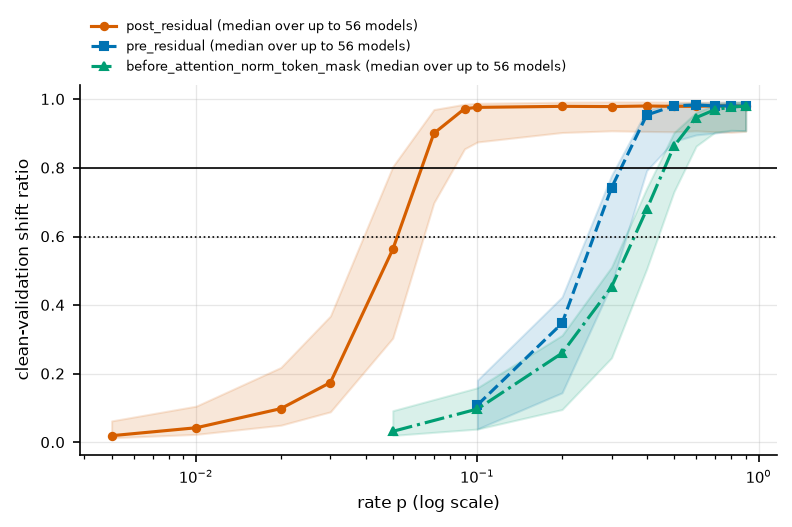

In [24]:
def shift_curves(reports, placement):
    by_rate = {}
    for report in reports.values():
        block = report["placements"].get(placement)
        if not block:
            continue
        for row in block["rates"]:
            sigma = row.get("shift_ratio", {}).get("validation")
            if sigma is not None:
                by_rate.setdefault(row["rate"], []).append(sigma)
    rates = sorted(by_rate)
    return rates, [np.percentile(by_rate[r], [25, 50, 75]) for r in rates], [len(by_rate[r]) for r in rates]


figure, axis = plt.subplots(figsize=(6.0, 3.2))
for placement, style in [(PUBLISHED_PLACEMENT, dict(color="#D55E00", marker="o", ls="-")), ("pre_residual", dict(color="#0072B2", marker="s", ls="--")), (RECOMMENDED_PLACEMENT, dict(color="#009E73", marker="^", ls="-."))]:
    rates, quartiles, counts = shift_curves(vit_reports, placement)
    quartiles = np.array(quartiles)
    axis.plot(rates, quartiles[:, 1], label=f"{placement} (median over up to {max(counts)} models)", markersize=3.5, **style)
    axis.fill_between(rates, quartiles[:, 0], quartiles[:, 2], color=style["color"], alpha=0.15)
axis.axhline(ADAPTIVE_SHIFT_TARGET, color="black", lw=0.8)
axis.axhline(PLACEMENT_MATCH_TARGET, color="black", lw=0.8, ls=":")
axis.set_xscale("log")
axis.set_xlabel("rate p (log scale)")
axis.set_ylabel("clean-validation shift ratio")
axis.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), fontsize=6)
plt.show()

**Reading the figure.** PSBD-RD's shift ratio rises far faster with the rate than the other 2 and reaches the adaptive target at rates several times lower than theirs, which is the compounding H3 described: its usable window lies at or below the 0.1 where the ConvNet grid started, and the sweep ladder in `configs/psbd_basis.json` reaches down into it. The other 2 placements need much larger rates for the same disturbance. The same nominal $p$ therefore means very different disturbances at different sites, which is H9's point.

**What it proves.** A comparison of placements at a shared rate compares strengths, not sites. H3 was refuted as stated (a good window exists at low rates) and H9 was supported. This is why every placement sweeps its own ladder, why the deployable rule picks each placement's own rate from clean data, and why the matched rule exists. **What it does not.** It says nothing yet about which site separates better once strength is equalized. **Next question.** With strength controlled, does moving dropout before the add help?

## Step 7. Before versus after the residual add (H1)

**Question.** Is dropout on each branch's output before it is added (`pre_residual`) better than dropout on the stream after the add (`post_residual`)?

**Hypothesis.** [H1](../docs/hypothesis/H1-pre-beats-post.md), the founding observation of the project: perturbing a branch's contribution leaves the stream itself intact and should hurt clean evidence without the compounding of step 6. The 2 halves of each are also shown: `before_attention_residual` and `before_mlp_residual` (the branch outputs), `after_attention_residual` and `after_mlp_residual` (the stream points). **Measured.** Every placement at both rules on the ViT panel, paired against PSBD-RD.

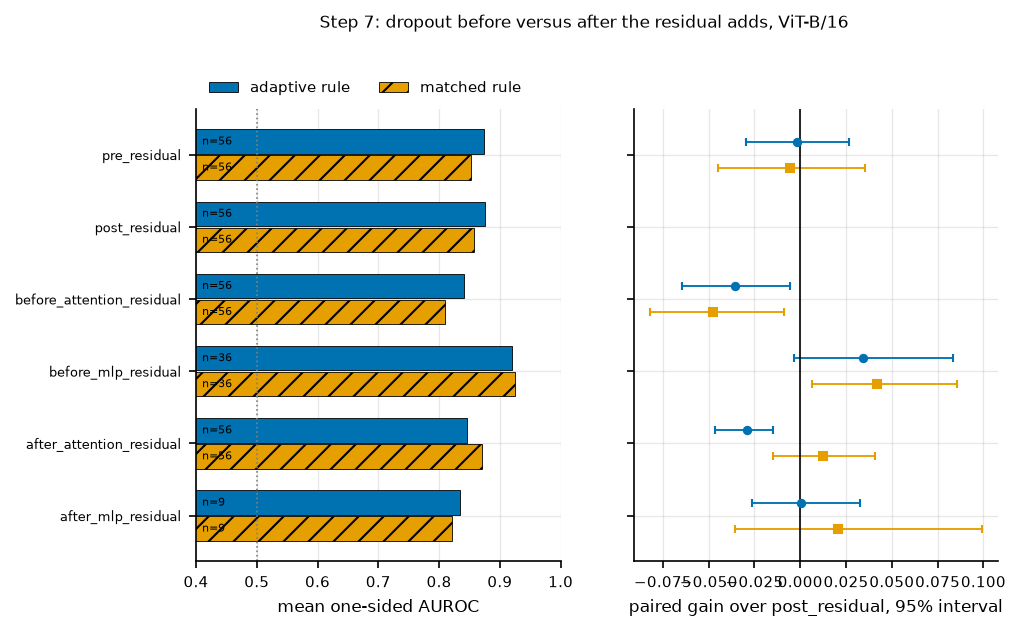

,n adaptive,AUROC adaptive,gain adaptive,n matched,AUROC matched,gain matched
placement,,,,,,
pre_residual,56,0.874,"-0.002 [-0.030, +0.026]",56,0.852,"-0.006 [-0.045, +0.035]"
post_residual,56,0.876,"+0.000 [+0.000, +0.000]",56,0.858,"+0.000 [+0.000, +0.000]"
before_attention_residual,56,0.840,"-0.035 [-0.065, -0.005]",56,0.810,"-0.047 [-0.082, -0.009]"
before_mlp_residual,36,0.920,"+0.034 [-0.003, +0.084]",36,0.924,"+0.042 [+0.006, +0.085]"
after_attention_residual,56,0.846,"-0.029 [-0.046, -0.015]",56,0.870,"+0.012 [-0.015, +0.041]"
after_mlp_residual,9,0.834,"+0.001 [-0.027, +0.032]",9,0.821,"+0.021 [-0.036, +0.099]"


In [25]:
step7 = ["pre_residual", PUBLISHED_PLACEMENT, "before_attention_residual", "before_mlp_residual", "after_attention_residual", "after_mlp_residual"]
compare(vit, step7, "Step 7: dropout before versus after the residual adds, ViT-B/16")
summary_table(vit, step7)

**What it proves.** `pre_residual` and `post_residual` are statistically tied at both rules on the current panel: the paired interval spans 0. H1 is refuted as a general claim. `before_mlp_residual` dropout was swept on only 37 models and `after_mlp_residual` dropout on only 9, so those 2 rows carry wide intervals and settle nothing alone. **What it does not.** It does not show that the site is irrelevant, only that the add is not the variable. **Next question.** If before or after the add does not matter, does it matter whether the perturbation lands on what a sublayer reads or on what the stream carries?

## Step 8. Sublayer input versus residual stream (H20)

**Question.** Is the useful split between perturbing a sublayer's input and perturbing the stream?

**Hypothesis.** [H20](../docs/hypothesis/H20-input-side-beats-residual-adjacent.md): an input-side perturbation (`after_embedding`, `before_attention_norm`, `before_attention`, `before_mlp_norm`, `before_mlp`) makes the sublayer compute on corrupted evidence, while a residual-adjacent one corrupts a sum the rest of the network can partly route around. On a balanced 12-model CIFAR-10 panel the input-side family won with an interval excluding 0. **Measured here.** The same family with dropout on the current panel.

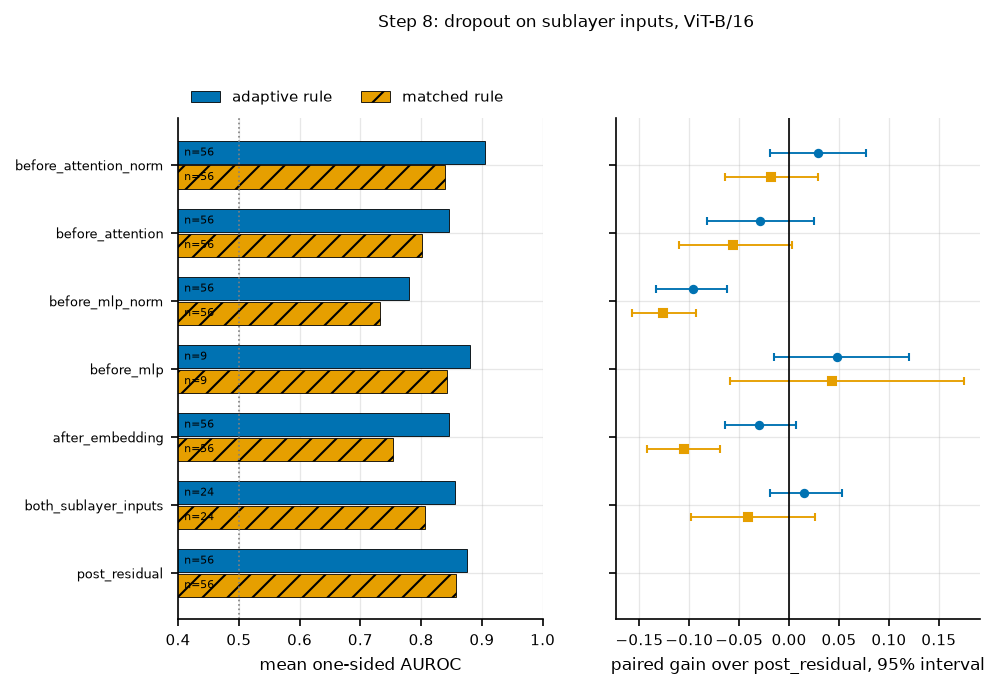

,n adaptive,AUROC adaptive,gain adaptive,n matched,AUROC matched,gain matched
placement,,,,,,
before_attention_norm,56,0.905,"+0.029 [-0.019, +0.077]",56,0.839,"-0.018 [-0.065, +0.029]"
before_attention,56,0.846,"-0.030 [-0.082, +0.025]",56,0.802,"-0.056 [-0.111, +0.003]"
before_mlp_norm,56,0.780,"-0.096 [-0.133, -0.062]",56,0.732,"-0.126 [-0.157, -0.094]"
before_mlp,9,0.881,"+0.048 [-0.016, +0.120]",9,0.843,"+0.043 [-0.059, +0.175]"
after_embedding,56,0.846,"-0.030 [-0.064, +0.007]",56,0.753,"-0.105 [-0.142, -0.069]"
both_sublayer_inputs,24,0.856,"+0.015 [-0.019, +0.053]",24,0.806,"-0.041 [-0.098, +0.026]"
post_residual,56,0.876,"+0.000 [+0.000, +0.000]",56,0.858,"+0.000 [+0.000, +0.000]"


In [26]:
step8 = ["before_attention_norm", "before_attention", "before_mlp_norm", "before_mlp", "after_embedding", "both_sublayer_inputs", PUBLISHED_PLACEMENT]
compare(vit, step8, "Step 8: dropout on sublayer inputs, ViT-B/16")
summary_table(vit, step8)

**What it proves.** With dropout the family effect does not replicate on the current panel. The attention input is within noise of PSBD-RD at the adaptive rule and below it in the point estimate at the matched rule, and the MLP input before its LayerNorm and the embedding output sit clearly below. H20's verdict rests on its smaller panel and has not been re-measured with this split on the current one, which is recorded here as a disagreement between the hypothesis doc and the ledger. **What it does not.** It does not rule out the input side: steps 12 and 13 show the input side winning once the operator changes. **Next question.** Perhaps dropout is the wrong unit, and the transformer's own units, heads, neurons or whole branches, should be removed instead.

## Step 9. Attention heads (H22, H35)

**Question.** Is the attention head, the transformer's own computational unit, the thing to remove?

**Hypothesis.** [H22](../docs/hypothesis/H22-head-mask-attention-units.md): a backdoor implemented as "attend to the trigger patch, write the target direction" might live in a few heads, and removing heads would collapse it while clean predictions, spread over many heads, survive. **Code path.** `attention_heads` swaps `self_attention.forward` for `masked_attention_forward` (step 3), which applies `HeadMask` to the (batch, 12, 197, 64) tensor before `out_proj`. **Measured.** `attention_heads_head_mask` on the 37 panel models it was swept on, against dropout at the attention input on the same axis.

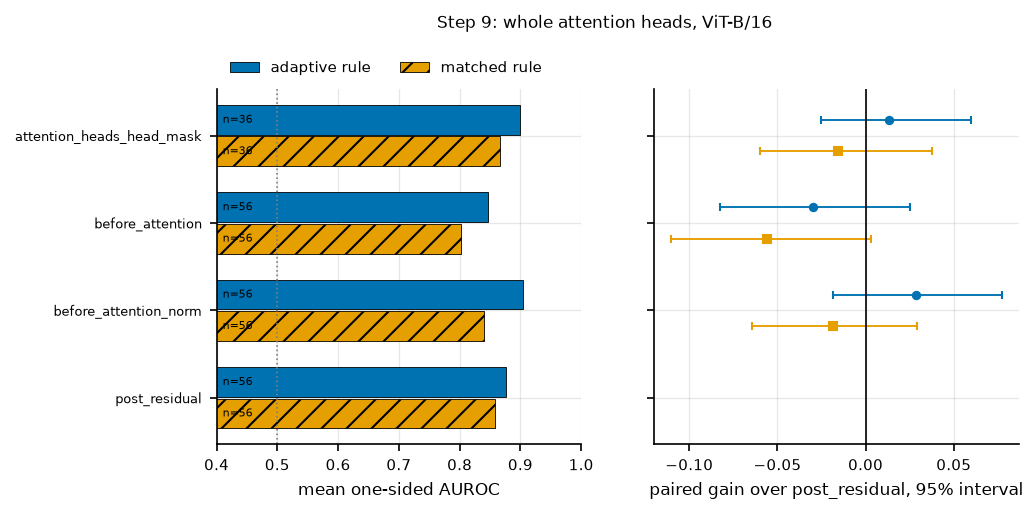

,n adaptive,AUROC adaptive,gain adaptive,n matched,AUROC matched,gain matched
placement,,,,,,
attention_heads_head_mask,36,0.899,"+0.013 [-0.025, +0.060]",36,0.867,"-0.016 [-0.060, +0.038]"
before_attention,56,0.846,"-0.030 [-0.082, +0.025]",56,0.802,"-0.056 [-0.111, +0.003]"
before_attention_norm,56,0.905,"+0.029 [-0.019, +0.077]",56,0.839,"-0.018 [-0.065, +0.029]"
post_residual,56,0.876,"+0.000 [+0.000, +0.000]",56,0.858,"+0.000 [+0.000, +0.000]"


In [27]:
step9 = ["attention_heads_head_mask", "before_attention", "before_attention_norm", PUBLISHED_PLACEMENT]
compare(vit, step9, "Step 9: whole attention heads, ViT-B/16")
summary_table(vit, step9)

**What it proves.** Head masking is within noise of PSBD-RD at both rules, so the head is not a privileged unit for this statistic. H22 records 3 reasons: heads are redundant, the backdoor is a single direction that no head is aligned with ([H16](../docs/hypothesis/H16-where-the-backdoor-neurons-are.md)), and 1 early head dominates every input alike ([H18](../docs/hypothesis/H18-sensitivity-profile-over-units.md)). [H35](../docs/hypothesis/H35-targeted-head-psbd.md) then masked the 3 heads [H31](../docs/hypothesis/H31-attention-divergence-backdoor-heads.md) found diverging on triggered inputs. That deterministic probe read near chance, so choosing the heads does not rescue the idea. **What it does not.** The attention map itself, as opposed to the head outputs, is probed by no position here. **Next question.** If not heads, perhaps whole features: MLP neurons or residual channels.

## Step 10. MLP neurons and whole channels (H16, H26)

**Question.** Does removing whole features, for every token at once, beat dropout's independent thinning?

**Hypothesis.** [H26](../docs/hypothesis/H26-channel-mask-structured-vs-elementwise.md): dropout never removes a feature (step 2) while `channel_mask` does. An early reading of [H16](../docs/hypothesis/H16-where-the-backdoor-neurons-are.md) placed the backdoor in a few residual dimensions. **Code path.** `mlp_neurons` is a pre-hook on `mlp.3`, whose input is the (batch, 197, 3072) hidden layer after GELU, so a channel there is 1 neuron. At the other positions a channel is 1 of the 768 residual features. **Measured.** Channel masking at every position it was swept at, with token masking at the same positions for contrast.

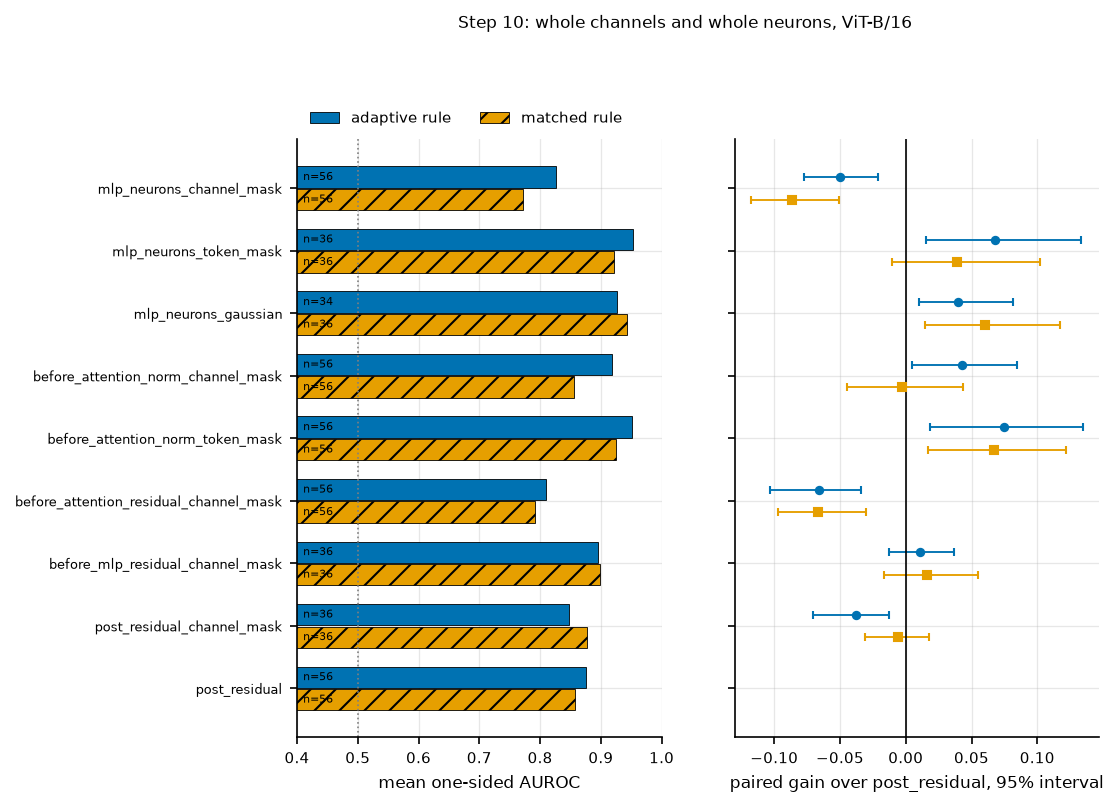

,n adaptive,AUROC adaptive,gain adaptive,n matched,AUROC matched,gain matched
placement,,,,,,
mlp_neurons_channel_mask,56,0.826,"-0.050 [-0.077, -0.021]",56,0.772,"-0.086 [-0.118, -0.051]"
mlp_neurons_token_mask,36,0.954,"+0.068 [+0.015, +0.133]",36,0.922,"+0.039 [-0.011, +0.102]"
mlp_neurons_gaussian,34,0.927,"+0.040 [+0.010, +0.082]",36,0.943,"+0.060 [+0.015, +0.117]"
before_attention_norm_channel_mask,56,0.919,"+0.043 [+0.005, +0.084]",56,0.855,"-0.003 [-0.045, +0.043]"
before_attention_norm_token_mask,56,0.951,"+0.075 [+0.018, +0.134]",56,0.925,"+0.067 [+0.017, +0.122]"
before_attention_residual_channel_mask,56,0.810,"-0.066 [-0.103, -0.034]",56,0.791,"-0.066 [-0.097, -0.030]"
before_mlp_residual_channel_mask,36,0.896,"+0.011 [-0.013, +0.037]",36,0.899,"+0.017 [-0.017, +0.055]"
post_residual_channel_mask,36,0.847,"-0.038 [-0.071, -0.013]",36,0.877,"-0.006 [-0.031, +0.018]"
post_residual,56,0.876,"+0.000 [+0.000, +0.000]",56,0.858,"+0.000 [+0.000, +0.000]"


In [28]:
step10 = ["mlp_neurons_channel_mask", "mlp_neurons_token_mask", "mlp_neurons_gaussian", "before_attention_norm_channel_mask", "before_attention_norm_token_mask", "before_attention_residual_channel_mask", "before_mlp_residual_channel_mask", "post_residual_channel_mask", PUBLISHED_PLACEMENT]
compare(vit, step10, "Step 10: whole channels and whole neurons, ViT-B/16")
summary_table(vit, step10)

**What it proves.** Removing whole neurons at `mlp_neurons` is clearly worse than PSBD-RD, and channel masking trails token masking at the same position almost everywhere. H26 is refuted as stated. H16's causal test gives the reason: removing the backdoor direction kills the attack while zeroing even hundreds of its largest coordinates does not, because the direction is not aligned with any coordinate axis, so no set of channels or neurons names it. The same `mlp_neurons` position does well with token masking or noise, so the position is not the problem, the unit is. **What it does not.** It does not show that the MLP is irrelevant to the backdoor. **Next question.** Perhaps the unit is a whole computation, a branch.

## Step 11. DropPath, the residual-native perturbation (H21)

**Question.** Does removing a whole branch computation, the stochastic depth ViT is trained with, beat damaging it?

**Hypothesis.** [H21](../docs/hypothesis/H21-droppath-residual-native.md): if the backdoor is written at a specific depth, removing the writing branch should suppress it while clean evidence, accumulated over many blocks, degrades gracefully. The pre-registration also stated how it could fail: a branch writes the backdoor and the clean signal together. **Code path.** `droppath` is allowed only at `before_attention_residual` and `before_mlp_residual`, 1 Bernoulli draw per sample broadcast over the (197, 768) branch output.

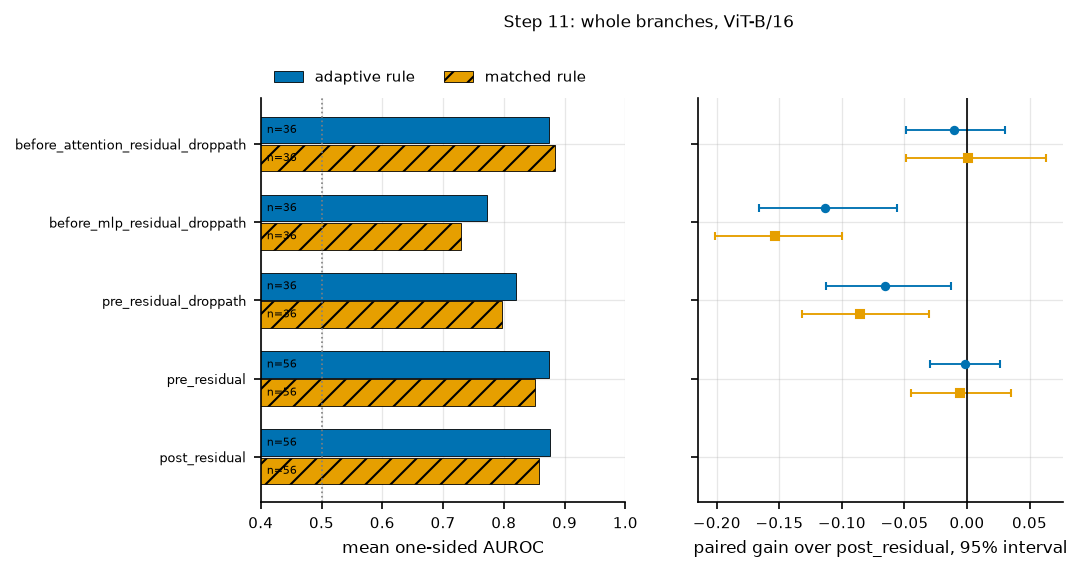

,n adaptive,AUROC adaptive,gain adaptive,n matched,AUROC matched,gain matched
placement,,,,,,
before_attention_residual_droppath,36,0.875,"-0.011 [-0.049, +0.030]",36,0.884,"+0.001 [-0.049, +0.063]"
before_mlp_residual_droppath,36,0.772,"-0.113 [-0.167, -0.056]",36,0.729,"-0.154 [-0.202, -0.100]"
pre_residual_droppath,36,0.820,"-0.065 [-0.112, -0.013]",36,0.797,"-0.085 [-0.132, -0.030]"
pre_residual,56,0.874,"-0.002 [-0.030, +0.026]",56,0.852,"-0.006 [-0.045, +0.035]"
post_residual,56,0.876,"+0.000 [+0.000, +0.000]",56,0.858,"+0.000 [+0.000, +0.000]"


In [29]:
step11 = ["before_attention_residual_droppath", "before_mlp_residual_droppath", "pre_residual_droppath", "pre_residual", PUBLISHED_PLACEMENT]
compare(vit, step11, "Step 11: whole branches, ViT-B/16")
summary_table(vit, step11)

**What it proves.** DropPath is at or below PSBD-RD at every site, confirming the losing half of H21's prediction: removing a computation removes the backdoor's contribution and the clean signal together, so the ratio PSU measures does not move. **What it does not.** The pre-registered follow-up, droppath restricted to the late blocks, was never run. **Next question.** The remaining unit is spatial, the token.

## Step 12. Whole tokens, and removal versus disturbance (H23, H27, H47)

**Question.** Does the token, the spatial unit, separate better? Does the operator need to remove anything at all?

**Hypotheses.** [H27](../docs/hypothesis/H27-token-mask-trigger-locality.md): a patch trigger covers a handful of the 196 patch tokens, so token masking is the only operator that can see trigger locality. [H23](../docs/hypothesis/H23-gaussian-noise-control.md): the PSBD paper's neuron-bias account says removal is what separates clean from triggered inputs, and isotropic noise, which removes nothing, is the control. [H47](../docs/hypothesis/H47-layernorm-absorbs-noise-not-masking.md): a LayerNorm divides each token by its own standard deviation, which additive noise inflates, so noise injected right before a LayerNorm is partly undone, while a zeroed token cannot be restored. **Measured.** The 4 operators at the attention input before its LayerNorm (`before_attention_norm`) and after it (`before_attention`), and noise before and after the MLP's LayerNorm.

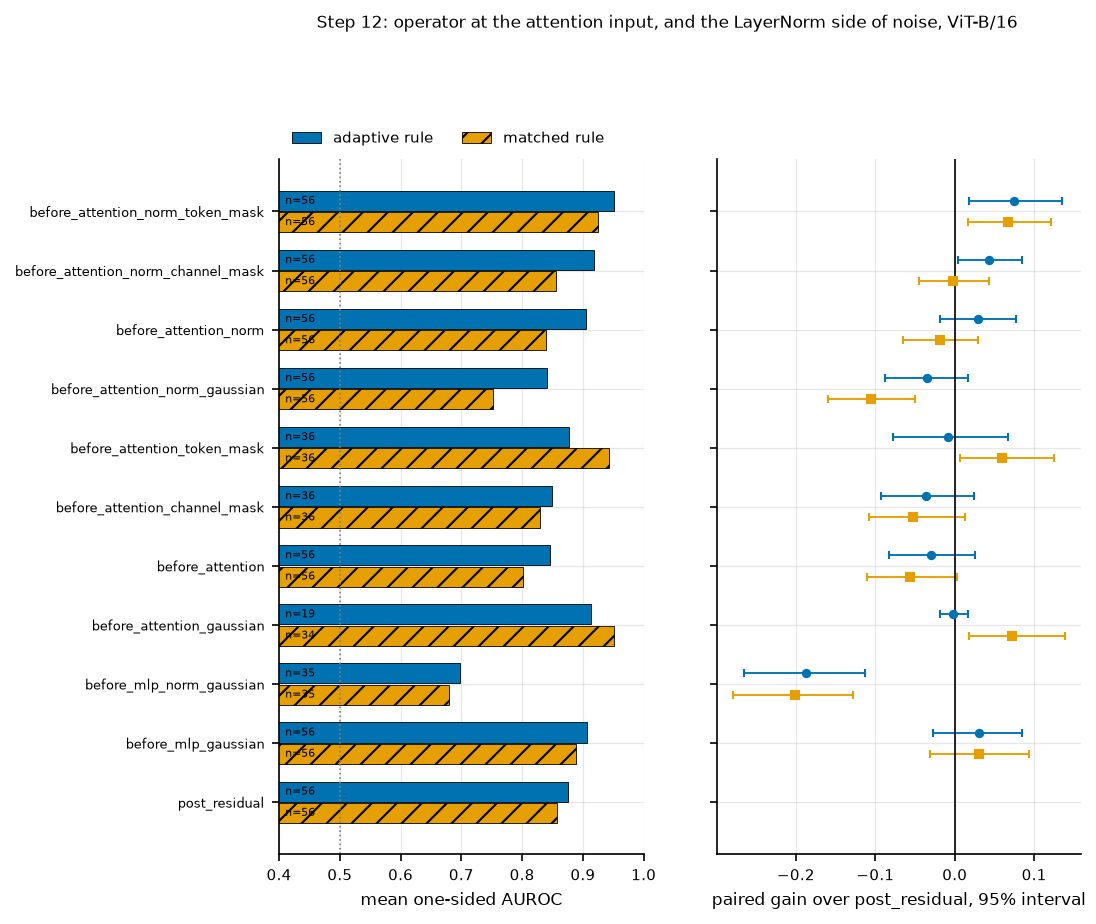

,n adaptive,AUROC adaptive,gain adaptive,n matched,AUROC matched,gain matched
placement,,,,,,
before_attention_norm_token_mask,56,0.951,"+0.075 [+0.018, +0.134]",56,0.925,"+0.067 [+0.017, +0.122]"
before_attention_norm_channel_mask,56,0.919,"+0.043 [+0.005, +0.084]",56,0.855,"-0.003 [-0.045, +0.043]"
before_attention_norm,56,0.905,"+0.029 [-0.019, +0.077]",56,0.839,"-0.018 [-0.065, +0.029]"
before_attention_norm_gaussian,56,0.840,"-0.035 [-0.088, +0.016]",56,0.752,"-0.105 [-0.160, -0.050]"
before_attention_token_mask,36,0.877,"-0.008 [-0.078, +0.067]",36,0.942,"+0.060 [+0.007, +0.125]"
before_attention_channel_mask,36,0.849,"-0.036 [-0.093, +0.025]",36,0.830,"-0.053 [-0.108, +0.013]"
before_attention,56,0.846,"-0.030 [-0.082, +0.025]",56,0.802,"-0.056 [-0.111, +0.003]"
before_attention_gaussian,19,0.913,"-0.002 [-0.019, +0.017]",34,0.951,"+0.072 [+0.019, +0.138]"
before_mlp_norm_gaussian,35,0.697,"-0.187 [-0.265, -0.113]",35,0.680,"-0.201 [-0.279, -0.129]"


In [30]:
step12 = [
    "before_attention_norm_token_mask", "before_attention_norm_channel_mask", "before_attention_norm", "before_attention_norm_gaussian",
    "before_attention_token_mask", "before_attention_channel_mask", "before_attention", "before_attention_gaussian",
    "before_mlp_norm_gaussian", "before_mlp_gaussian", PUBLISHED_PLACEMENT,
]
compare(vit, step12, "Step 12: operator at the attention input, and the LayerNorm side of noise, ViT-B/16")
summary_table(vit, step12)

**What it proves.** At the attention input before its LayerNorm, token masking is the best operator at both rules and noise the worst. Moved after the LayerNorm, noise becomes one of the best placements at the matched rule while token masking barely changes, and the same reversal holds at the MLP input. That is H47's prediction, and it means the operator ranking depends on the side of a LayerNorm rather than on the site, the correction recorded as Q19 in `docs/open-questions.md`. H23 is refuted as a requirement: removal is not needed where no LayerNorm follows. Note the n columns: noise after the attention LayerNorm reached the adaptive target on only part of the models, so its adaptive mean is read on an easier subset and only its paired gain may be compared. **What it does not.** It does not say why token masking separates patch triggers. **Next question.** Holding the operator at token masking, which site in the block?

## Step 13. Where the token mask should act

**Question.** With the operator fixed at `token_mask`, is the attention input the right site, compared with the MLP input, the attention branch output (the twin) and the stream?

**Hypotheses.** At the attention input, before mixing, a masked token takes no part in that block's attention, so the class token cannot read the trigger through it there. At the MLP input, after mixing, the class token has already gathered what attention routed to it, and the MLP is token-wise and moves nothing between tokens ([H49](../docs/hypothesis/H49-backdoor-is-routed-not-computed.md)). The branch output before the add is the attention input's twin, since zeroing a token's own attention contribution removes much the same thing. The stream after the add removes the token's accumulated content outright. **Measured.** The 4 sites plus the combination of both LayerNorm inputs, first as means and gains, then per attack at the adaptive rule. The per-attack figure's x axis is the attack with its model count and the bars are the mean AUROC of each site.

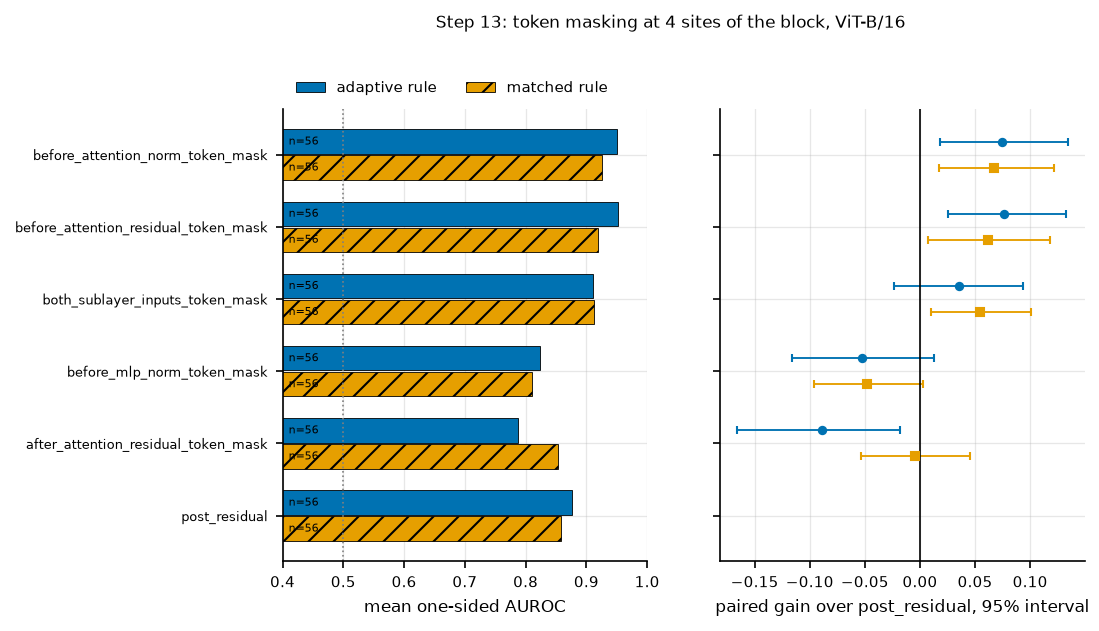

,n adaptive,AUROC adaptive,gain adaptive,n matched,AUROC matched,gain matched
placement,,,,,,
before_attention_norm_token_mask,56,0.951,"+0.075 [+0.018, +0.134]",56,0.925,"+0.067 [+0.017, +0.122]"
before_attention_residual_token_mask,56,0.952,"+0.076 [+0.025, +0.133]",56,0.919,"+0.062 [+0.007, +0.118]"
both_sublayer_inputs_token_mask,56,0.911,"+0.035 [-0.024, +0.094]",56,0.912,"+0.054 [+0.010, +0.101]"
before_mlp_norm_token_mask,56,0.823,"-0.053 [-0.116, +0.012]",56,0.810,"-0.048 [-0.096, +0.003]"
after_attention_residual_token_mask,56,0.787,"-0.089 [-0.166, -0.018]",56,0.854,"-0.004 [-0.053, +0.046]"
post_residual,56,0.876,"+0.000 [+0.000, +0.000]",56,0.858,"+0.000 [+0.000, +0.000]"


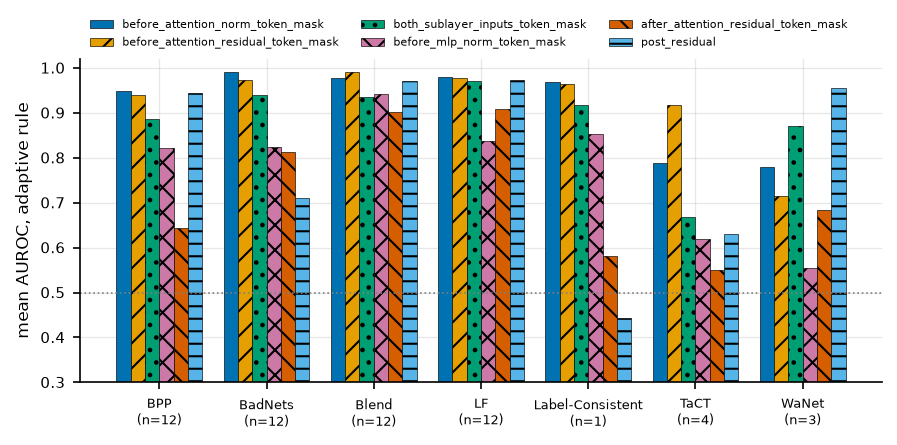

In [31]:
step13 = [RECOMMENDED_PLACEMENT, "before_attention_residual_token_mask", "both_sublayer_inputs_token_mask", "before_mlp_norm_token_mask", "after_attention_residual_token_mask", PUBLISHED_PLACEMENT]
compare(vit, step13, "Step 13: token masking at 4 sites of the block, ViT-B/16")
display(summary_table(vit, step13))

attacks = sorted({cell["attack"] for cell in vit_cells}, key=attack_label)
figure, axis = plt.subplots(figsize=(6.9, 2.8))
width = 0.8 / len(step13)
hatches = ["", "//", "..", "xx", "\\\\", "--"]
for index, placement in enumerate(step13):
    values = vit["adaptive"].get(placement, {})
    means = []
    for attack in attacks:
        attack_values = [v for folder, v in values.items() if cell_of[folder]["attack"] == attack]
        means.append(statistics.mean(attack_values) if attack_values else np.nan)
    axis.bar(np.arange(len(attacks)) + (index - len(step13) / 2 + 0.5) * width, means, width=width, label=placement, hatch=hatches[index], edgecolor="black", linewidth=0.3)
counts = pd.Series([cell["attack"] for cell in vit_cells]).value_counts()
axis.set_xticks(range(len(attacks)), labels=[f"{attack_label(a)}\n(n={counts[a]})" for a in attacks], fontsize=6)
axis.axhline(0.5, color="0.5", lw=0.8, ls=":")
axis.set_ylim(0.3, 1.02)
axis.set_ylabel("mean AUROC, adaptive rule")
axis.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), fontsize=5.5, ncols=3)
plt.show()

**What it proves.** The attention input is the best token-mask site, the branch output twin is level with it at the adaptive rule, the MLP input is clearly worse and the stream is worst. Per attack, the attention input's advantage over PSBD-RD comes from the patch triggers BadNets and TaCT, and on WaNet and the single SIG model PSBD-RD is ahead. `experiments/why_token_masking_works/README.md` measured the mechanism: a token masked at the attention input keeps its entry in the residual stream, the class token reads a patch trigger mostly in the last blocks, and the trigger's few tokens are rarely masked in every late block at the adaptive rate, so the triggered prediction survives while clean evidence does not. Dropout on the stream corrupts the trigger tokens' stored content in every block, so there the triggered prediction breaks as easily as a clean one. **What it does not.** On ViT the attention input and its twin are tied, and the declared selection half of the panel would have picked the twin (Q20 of `docs/open-questions.md`). Step 16 shows the architecture that separates them. **Next question.** Do the perturbations of other published detectors, run inside the same statistic, do as well?

## Step 14. Ported perturbations from IBD-PSC and SCALE-UP (H17, H28)

**Question.** Are parameter amplification and pixel amplification as good as the activation probes when scored by the same statistic?

**Hypothesis.** [H28](../docs/hypothesis/H28-perturbation-consistency-is-margin-estimation.md): PSBD, SCALE-UP, IBD-PSC and STRIP are 1 method, perturbation consistency as an estimate of the decision margin, with 4 choices of where to perturb. **Code path.** `gain_scale` at `attention_norm_out`, `mlp_norm_out` and `final_norm_out` is IBD-PSC's LayerNorm amplification as a post-hook. `scale_up` at `input_pixels` is SCALE-UP's amplification before the Resize. Both are deterministic, so 1 pass is exact and their shift ratio flips per sample rather than per pass.

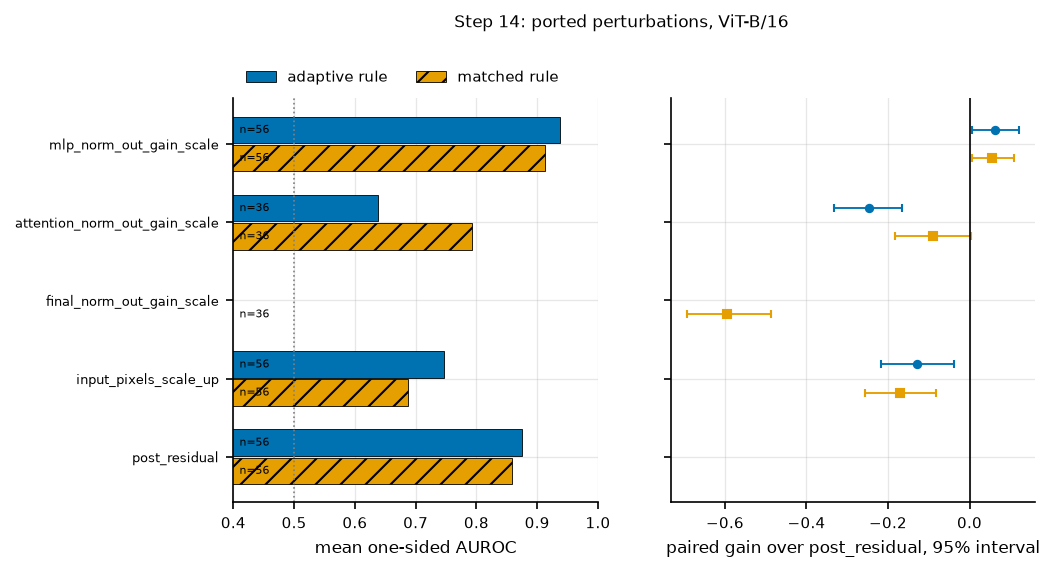

,n adaptive,AUROC adaptive,gain adaptive,n matched,AUROC matched,gain matched
placement,,,,,,
mlp_norm_out_gain_scale,56,0.938,"+0.062 [+0.007, +0.121]",56,0.913,"+0.055 [+0.007, +0.109]"
attention_norm_out_gain_scale,36,0.638,"-0.247 [-0.332, -0.167]",36,0.793,"-0.090 [-0.183, +0.003]"
final_norm_out_gain_scale,0,NaN,NaN,36,0.287,"-0.596 [-0.692, -0.486]"
input_pixels_scale_up,56,0.747,"-0.129 [-0.218, -0.038]",56,0.687,"-0.171 [-0.258, -0.083]"
post_residual,56,0.876,"+0.000 [+0.000, +0.000]",56,0.858,"+0.000 [+0.000, +0.000]"


In [32]:
step14 = ["mlp_norm_out_gain_scale", "attention_norm_out_gain_scale", "final_norm_out_gain_scale", "input_pixels_scale_up", PUBLISHED_PLACEMENT]
compare(vit, step14, "Step 14: ported perturbations, ViT-B/16")
summary_table(vit, step14)

**What it proves.** Gain scale at the MLP LayerNorm output is above PSBD-RD with an interval spanning 0, and at the attention LayerNorm output and the final LayerNorm it is far worse. The final-norm row is below chance at the matched rule and never reaches the adaptive target: amplifying what the head reads inflates every logit and makes every prediction more confident, clean or triggered. Pixel amplification is near the bottom of the grid. An earlier headline for gain scale at the MLP norm output, in [H17](../docs/hypothesis/H17-low-poison-rate-is-a-placement-artifact.md), is withdrawn: it compared a placement read at a far higher clean disturbance than its baseline (`docs/audit-2026-09-07.md`). **What it does not.** These rows score the ported perturbations with PSU. The full detectors, with their own statistics, are compared in `notebooks/competitor-defenses.ipynb`. **Next question.** Should the perturbation act in every block?

## Step 15. Depth bands (H10, H38)

**Question.** Does perturbing only the blocks where the backdoor direction is written beat perturbing all of them?

**Hypothesis.** [H10](../docs/hypothesis/H10-depth-band-placement.md), from [H4](../docs/hypothesis/H4-placement-is-attack-dependent.md) and [H30](../docs/hypothesis/H30-residual-persistence-phase-transition.md): the backdoor direction crystallizes late and at attack-dependent depths ([H38](../docs/hypothesis/H38-crystallization-depth-vs-placement.md)), so a band aimed there concentrates the perturbation where it separates. **Code path.** `plug_dropout(..., block_range=(first, last))` attaches only to blocks `first` to `last`, 1-indexed and inclusive. **Measured.** Dropout before the adds and token masking at the attention input, each in 3 bands of 4 blocks and in all 12.

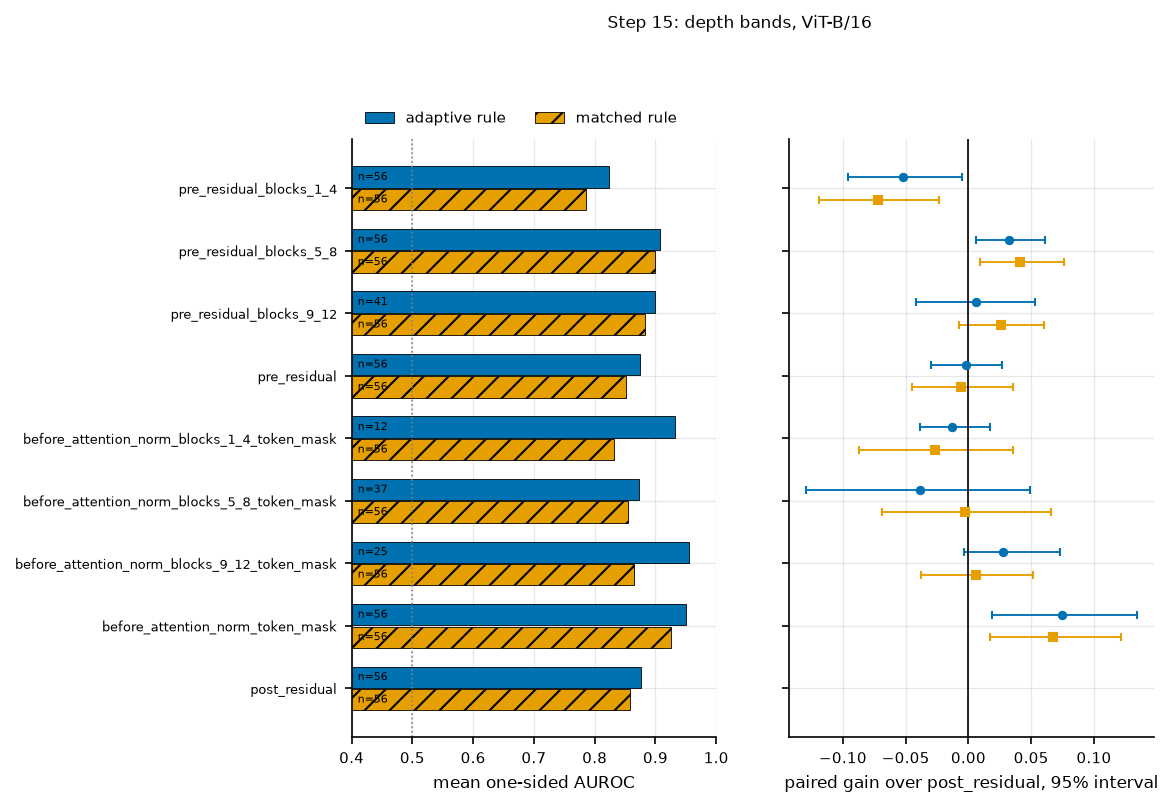

,n adaptive,AUROC adaptive,gain adaptive,n matched,AUROC matched,gain matched
placement,,,,,,
pre_residual_blocks_1_4,56,0.824,"-0.052 [-0.096, -0.005]",56,0.785,"-0.072 [-0.119, -0.024]"
pre_residual_blocks_5_8,56,0.908,"+0.032 [+0.006, +0.061]",56,0.899,"+0.041 [+0.009, +0.076]"
pre_residual_blocks_9_12,41,0.900,"+0.006 [-0.042, +0.053]",56,0.883,"+0.026 [-0.007, +0.060]"
pre_residual,56,0.874,"-0.002 [-0.030, +0.026]",56,0.852,"-0.006 [-0.045, +0.035]"
before_attention_norm_blocks_1_4_token_mask,12,0.932,"-0.013 [-0.038, +0.017]",56,0.831,"-0.026 [-0.087, +0.036]"
before_attention_norm_blocks_5_8_token_mask,37,0.872,"-0.039 [-0.130, +0.049]",56,0.855,"-0.002 [-0.069, +0.066]"
before_attention_norm_blocks_9_12_token_mask,25,0.955,"+0.027 [-0.003, +0.073]",56,0.864,"+0.006 [-0.038, +0.051]"
before_attention_norm_token_mask,56,0.951,"+0.075 [+0.018, +0.134]",56,0.925,"+0.067 [+0.017, +0.122]"
post_residual,56,0.876,"+0.000 [+0.000, +0.000]",56,0.858,"+0.000 [+0.000, +0.000]"


In [33]:
step15 = ["pre_residual_blocks_1_4", "pre_residual_blocks_5_8", "pre_residual_blocks_9_12", "pre_residual", "before_attention_norm_blocks_1_4_token_mask", "before_attention_norm_blocks_5_8_token_mask", "before_attention_norm_blocks_9_12_token_mask", RECOMMENDED_PLACEMENT, PUBLISHED_PLACEMENT]
compare(vit, step15, "Step 15: depth bands, ViT-B/16")
summary_table(vit, step15)

**What it proves.** The answer depends on the operator. For dropout before the adds, the middle band beats both the full stack and PSBD-RD with an interval above 0 at both rules, and the early band is worse. For token masking at the attention input, every band trails the full stack at the matched rule. At the adaptive rule the token-mask bands reach the 0.8 target on only part of the panel (the n column), because masking in 4 blocks rarely disturbs a clean prediction that much, so their adaptive means are read on a different and easier subset. Only paired gains may be compared, which Q26 and Q38 of `docs/open-questions.md` record. H10's rule for choosing the band from the direction's onset layer was refuted by its own pre-registered out-of-sample test. **What it does not.** No band is recommended for deployment, because a defender cannot choose a band per attack. **Next question.** Is any of this specific to ViT-B/16?

## Step 16. Transfer to Swin-S

**Question.** Is the result a property of ViT-B/16 or of transformers?

**Why Swin.** It differs in exactly the ways that could break the mechanism: windowed attention instead of global, no class token (the head averages every token), 4 stages with patch merging and 24 blocks. **Measured.** The same comparison on the Swin panel of `swin_cells`, which the paper reads, against Swin's own PSBD-RD. The Swin panel is not the same set of attacks and rates as the ViT panel, and Swin's bands are 1 to 8, 9 to 16 and 17 to 24.

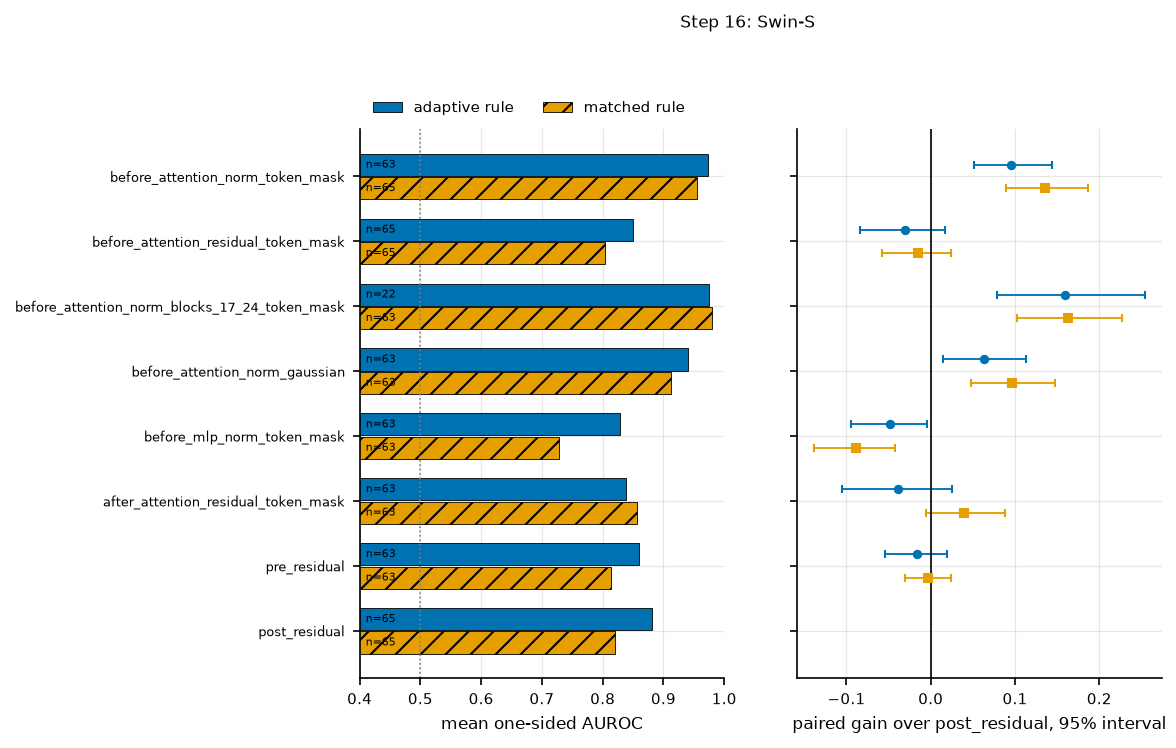

,n adaptive,AUROC adaptive,gain adaptive,n matched,AUROC matched,gain matched
placement,,,,,,
before_attention_norm_token_mask,63,0.973,"+0.096 [+0.051, +0.144]",65,0.955,"+0.135 [+0.089, +0.187]"
before_attention_residual_token_mask,65,0.850,"-0.031 [-0.084, +0.017]",65,0.804,"-0.015 [-0.058, +0.024]"
before_attention_norm_blocks_17_24_token_mask,22,0.975,"+0.159 [+0.079, +0.254]",63,0.980,"+0.163 [+0.102, +0.227]"
before_attention_norm_gaussian,63,0.940,"+0.063 [+0.015, +0.113]",63,0.913,"+0.096 [+0.047, +0.147]"
before_mlp_norm_token_mask,63,0.828,"-0.049 [-0.094, -0.004]",63,0.728,"-0.089 [-0.139, -0.042]"
after_attention_residual_token_mask,63,0.838,"-0.038 [-0.105, +0.026]",63,0.856,"+0.039 [-0.006, +0.088]"
pre_residual,63,0.860,"-0.016 [-0.054, +0.019]",63,0.814,"-0.003 [-0.030, +0.024]"
post_residual,65,0.881,"+0.000 [+0.000, +0.000]",65,0.819,"+0.000 [+0.000, +0.000]"


In [34]:
step16 = [RECOMMENDED_PLACEMENT, "before_attention_residual_token_mask", "before_attention_norm_blocks_17_24_token_mask", "before_attention_norm_gaussian", "before_mlp_norm_token_mask", "after_attention_residual_token_mask", "pre_residual", PUBLISHED_PLACEMENT]
compare(swin, step16, "Step 16: Swin-S")
summary_table(swin, step16)

**What it proves.** On Swin token masking at the attention input is at the top at both rules with a paired gain over PSBD-RD whose interval is well above 0, and here it separates from its branch-output twin, which sits near PSBD-RD. That is the evidence the recommendation of the attention input over its twin rests on (Q20 of `docs/open-questions.md`). The late band is strong on Swin too, and noise before the attention LayerNorm does better on Swin than on ViT. **What it does not.** Swin's panel is read without a coverage ledger of its own, so its population rules are those of `scripts/paper/tab_swin.py`. **Next question.** What does the whole grid look like at once?

## Step 17. The whole grid at once

**Question.** Taken together, does the position or the operator move detection more?

**Measured.** Every ViT placement without a band, arranged as a position by operator grid of mean AUROC at the matched rule, where placements are compared at equal disturbance. Each cell shows the mean and, below it, the model count. An empty cell was never swept, either because the pair is forbidden (step 2) or because nobody ran it. The color scale is centered on chance so an inverted cell reads red. The grid shows means over different model subsets, so a cell with small n should be read with its paired gain in `docs/placement-rationale.md`'s ledger.

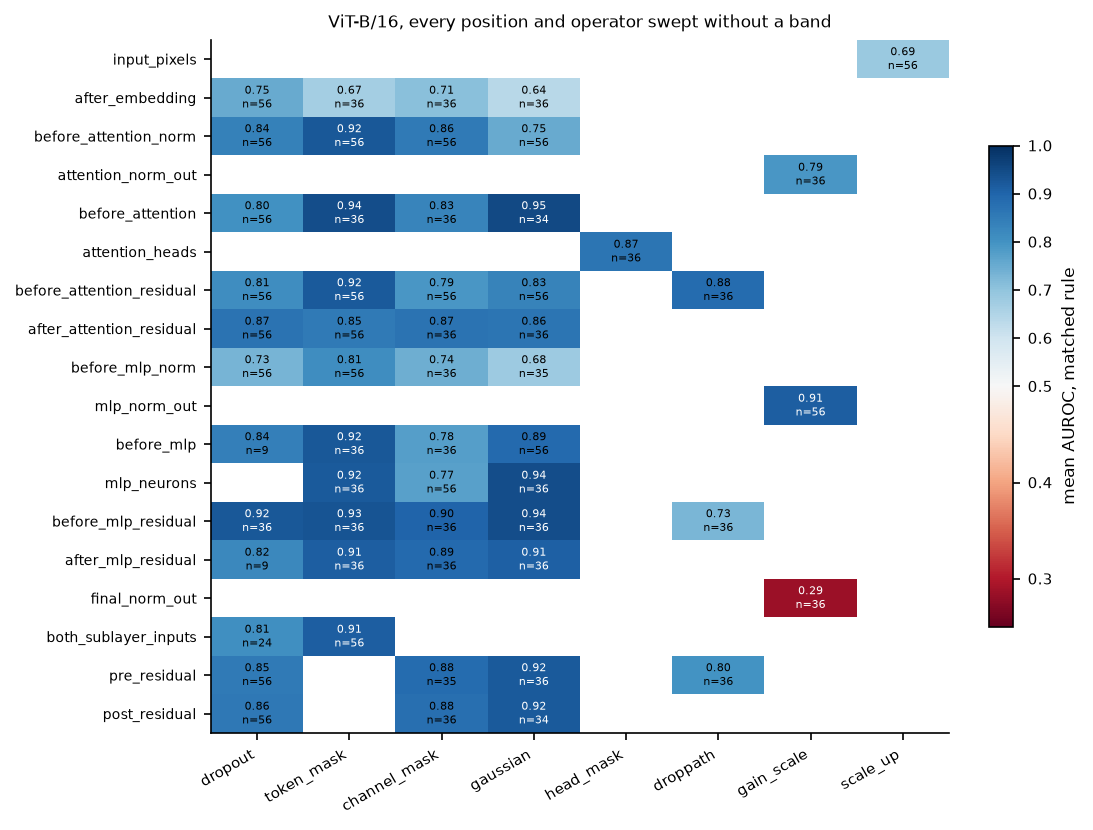

In [35]:
grid_rows = []
for placement, values in vit["matched"].items():
    parts = split_placement(placement)
    if parts["block_range"] is not None:
        continue
    grid_rows.append({"position": parts["position"], "operator": parts["operator"], "auroc": statistics.mean(values.values()), "n": len(values)})
grid = pd.DataFrame(grid_rows)
position_order = ["input_pixels", "after_embedding", "before_attention_norm", "attention_norm_out", "before_attention", "attention_heads", "before_attention_residual", "after_attention_residual", "before_mlp_norm", "mlp_norm_out", "before_mlp", "mlp_neurons", "before_mlp_residual", "after_mlp_residual", "final_norm_out", "both_sublayer_inputs", "pre_residual", "post_residual"]
operator_order = ["dropout", "token_mask", "channel_mask", "gaussian", "head_mask", "droppath", "gain_scale", "scale_up"]
means = grid.pivot(index="position", columns="operator", values="auroc").reindex(index=[p for p in position_order if p in set(grid["position"])], columns=[o for o in operator_order if o in set(grid["operator"])])
counts = grid.pivot(index="position", columns="operator", values="n").reindex_like(means)

from matplotlib.colors import TwoSlopeNorm

figure, axis = plt.subplots(figsize=(6.9, 6.0))
image = axis.imshow(means.to_numpy(dtype=float), cmap="RdBu", norm=TwoSlopeNorm(vmin=0.25, vcenter=0.5, vmax=1.0), aspect="auto")
for row in range(means.shape[0]):
    for column in range(means.shape[1]):
        value = means.iat[row, column]
        if not np.isnan(value):
            axis.text(column, row, f"{value:.2f}\nn={int(counts.iat[row, column])}", ha="center", va="center", fontsize=5.5, color="white" if value > 0.9 or value < 0.35 else "black")
axis.set_xticks(range(means.shape[1]), labels=means.columns, rotation=30, ha="right")
axis.set_yticks(range(means.shape[0]), labels=means.index, fontsize=6.5)
axis.grid(False)
figure.colorbar(image, ax=axis, fraction=0.03, label="mean AUROC, matched rule")
axis.set_title("ViT-B/16, every position and operator swept without a band", fontsize=8)
plt.show()

**What it proves.** Neither axis explains the other. Along a row the operator moves a site by a large amount, and down a column the site moves an operator by a similar amount, which is why the basis is a grid rather than a list. The top of the grid at this rule is token masking at the attention input and noise at sites that no LayerNorm directly follows. The bottom is the embedding output, noise right before a LayerNorm and the ported amplifications. `rademacher`, `token_substitute` and `token_block_mask` exist with tests and have no column, because no cache exists for them on any panel model. **What it does not.** A grid of means ranks nothing by itself, since the columns rest on different subsets, and the ranking of 27 declared placements is exploratory with no multiplicity control (Q30 of `docs/open-questions.md`).

## Step 18. Summary

The sweep reads as 1 argument. The original site works on the architecture it was designed for (step 5). On ViT it first looked broken because the ConvNet rate grid started past its operating window, which forced every comparison onto matched disturbance (step 6). With strength controlled, before or after the add does not matter (step 7), and with dropout neither does input versus stream on the current panel, against what H20 found on its smaller panel (step 8). The transformer's own units, heads, neurons and whole branches, are all worse units than dropout's thinning (steps 9 to 11), because the backdoor is a single direction no unit is aligned with. The token is the unit that works, and removal is not what makes it work: noise does as well wherever no LayerNorm follows, and a LayerNorm right after the probe absorbs noise but not a mask (step 12). Within the block the attention input is the best site for the token mask, tied with its branch-output twin on ViT and clearly ahead of it on Swin, because the class token reads a patch trigger late and the input-side mask leaves the trigger's stored content intact while destroying diffuse clean evidence (steps 13 and 16). The perturbations of other detectors score lower inside the same statistic (step 14), and restricting to depth bands helps dropout but not the token mask (step 15).

What remains open is listed in `docs/open-questions.md`: the ViT twin tie (Q20), the band n caveat (Q26, Q38), the unmeasured operators of step 2 and the family split of step 8, which has not been re-measured with the current panel's balance.